# Free Space Path Loss (FSPL)

Model the signal loss as the distance increases by modelling it using FSPL equations.

$$
FSPL = 20log(d) + 20log(f) - 147.55 - G_t - G_r
$$

Where:
- FSPL is in dB
- $d$ is the distance from the transmitter
- $f$ is the frequency of the wave, so 24MHz
- $G_t$ is the transmitter's gain
- $G_r$ is the receiver's gain. It's assumed this is 1 as the antenna is isotropic?

References:
- https://en.wikipedia.org/wiki/Free-space_path_loss
- https://www.pasternack.com/t-calculator-fspl.aspx
- https://www.bdamax.com/blog/db-vs-dbm-whats-the-real-difference/

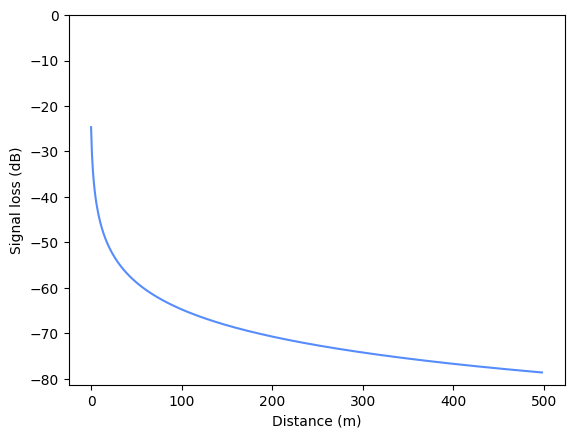

In [1]:
from BleFinley.fspl import *

points = []

for x in range (1, 500, 1):
    points.append(signal_loss(x) * - 1)

plt.plot(points)
plt.ylim(ymax=0)
plt.xlabel("Distance (m)")
plt.ylabel("Signal loss (dB)")
plt.show()

## In-Depth Estimated vs Actual RSS for Straight Path 5

Model what the FSPL equation estimates the RSS should be at a given distance from the transmitter and compare this to the actual signal strength received by the tag. By cross-referencing the normalised time stamps of the GPS receiver and tag, plot the RSS of the packets when the tag is a given distance away from the transmitter.

Looks at `/March 26 2025 Field Trial/straightpath5/` experiment, where the device moved ~181m from transmitter E to transmitter B.

### Conclusion

The attenuation of the BLE signal mildly resemble the model of signal loss using FSPL equations.

### Overview of GPS and Log Data

Analyse aspects of the GPS file to understand it better and plot some general information about the Bluetooth logs from the tags.

In [2]:
from BleFinley import *

# hard code transmitter locations. Altitudes from https://glandnav.com/tools/gps-elevation-finder
tx_a = Transmitter('a', -1.448596, 53.368606, 131.0 + 1.5)
tx_b = Transmitter('b', -1.448626, 53.367865, 131.0 + 1.5)
tx_c = Transmitter('c', -1.450168, 53.368359, 122.0 + 1.5)
tx_e = Transmitter('e', -1.449990, 53.369204, 118.0 + 1.5) #113.0)

In [3]:
from copy import deepcopy

# extract tag log data and gps data and convert them into objects
gps_data = GpsLog("/home/finley/Git/BLEanalysis/bluetooth_experiments/March 26 2025 Field Trial/straightpath5/2025-03-26_11_50_22_my_iOS_device.csv")

log_a = BleLog("/home/finley/Git/BLEanalysis/bluetooth_experiments/March 26 2025 Field Trial/straightpath5/straightpath5noperson.log", tx_a, deepcopy(gps_data))
log_b = BleLog("/home/finley/Git/BLEanalysis/bluetooth_experiments/March 26 2025 Field Trial/straightpath5/straightpath5noperson.log", tx_b, deepcopy(gps_data))
log_c = BleLog("/home/finley/Git/BLEanalysis/bluetooth_experiments/March 26 2025 Field Trial/straightpath5/straightpath5noperson.log", tx_c, deepcopy(gps_data))
log_e = BleLog("/home/finley/Git/BLEanalysis/bluetooth_experiments/March 26 2025 Field Trial/straightpath5/straightpath5noperson.log", tx_e, deepcopy(gps_data))

GpsLog | no. points: 164, time: 162.999
BleLog | tx: a, no.packets: 3756, time: 162.999s
BleLog | tx: b, no.packets: 5690, time: 162.999s
BleLog | tx: c, no.packets: 7917, time: 162.999s
BleLog | tx: e, no.packets: 5306, time: 162.999s


[]

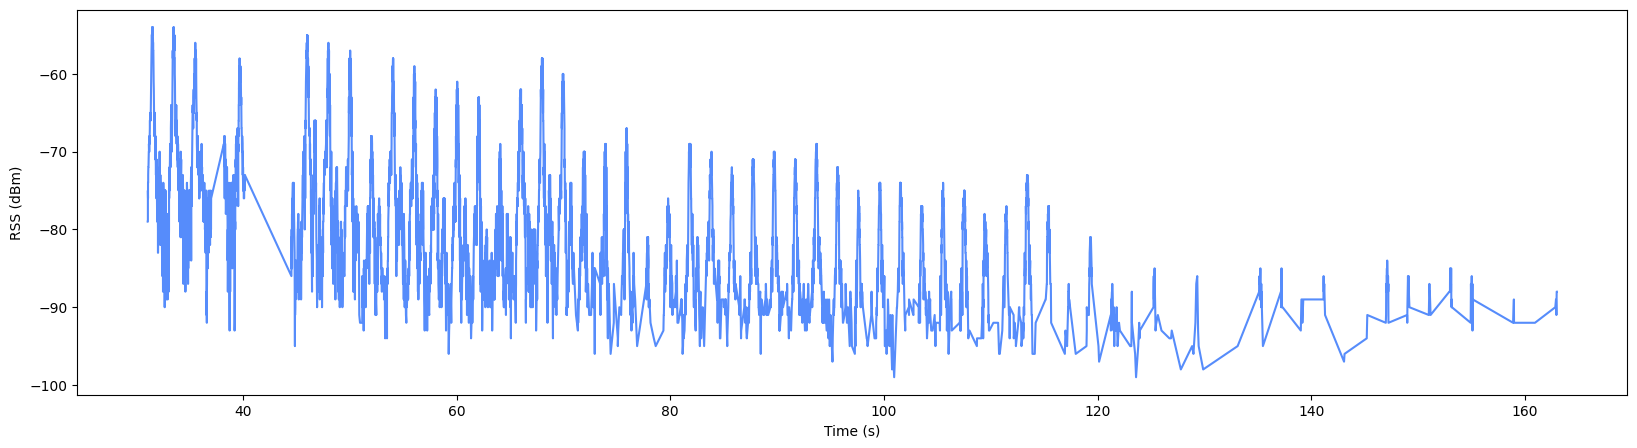

In [4]:
plt.figure(figsize=(20, 5))
# plt.title("RSS over Time")
plt.ylabel("RSS (dBm)")
plt.xlabel("Time (s)")
plt.plot(log_e.all_times(), log_e.all_rss())
plt.plot()

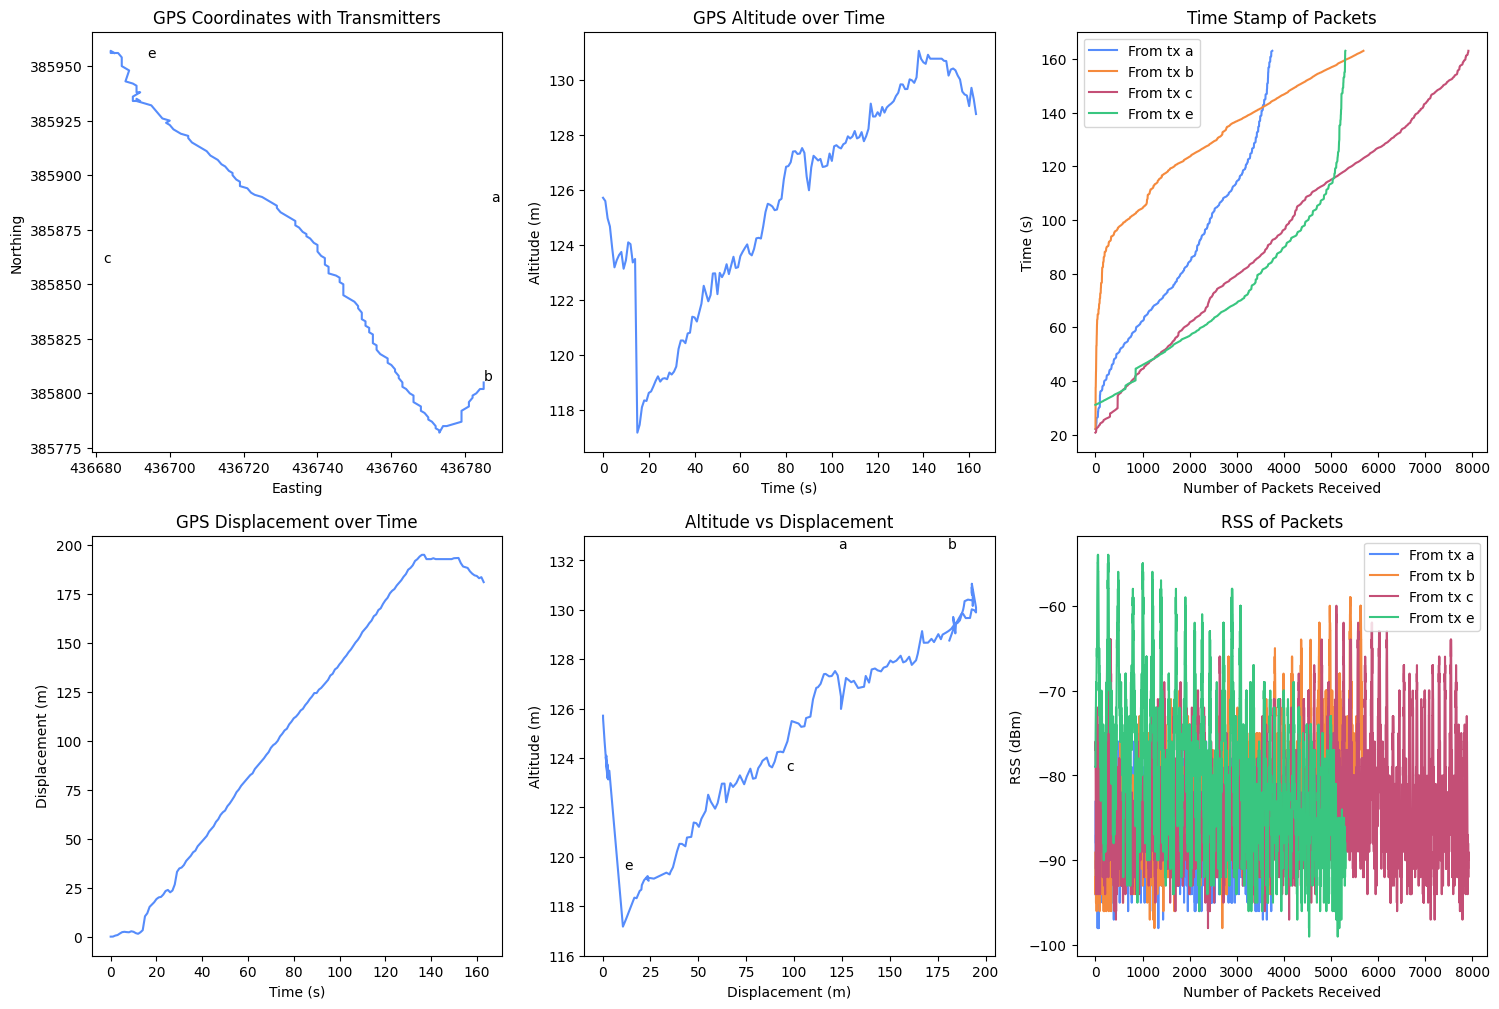

In [5]:
# plot gps coordinates and rss over time on a graph
plt.figure(figsize=(18, 12))

plt.subplot(2, 3, 1)
plt.title("GPS Coordinates with Transmitters")
plt.plot(gps_data.get_eastings(), gps_data.get_northings())
for tx in (tx_a, tx_b, tx_c, tx_e):
    plt.annotate(tx.tx_id, (tx.easting, tx.northing))
plt.ylabel("Northing")
plt.xlabel("Easting")

plt.subplot(2, 3, 2)
plt.title("GPS Altitude over Time")
plt.plot(gps_data.get_relative_times(), gps_data.get_altitudes())
plt.ylabel("Altitude (m)")
plt.xlabel("Time (s)")

plt.subplot(2, 3, 3)
plt.title("Time Stamp of Packets")
for log in [log_a, log_b, log_c, log_e]:
    plt.plot(log.all_times(), label=f"From tx {log.transmitter.tx_id}")
plt.ylabel("Time (s)")
plt.xlabel("Number of Packets Received")
plt.legend()

plt.subplot(2, 3, 4)
plt.title("GPS Displacement over Time")
plt.plot(gps_data.get_relative_times(), gps_data.get_displacements())
plt.ylabel("Displacement (m)")
plt.xlabel("Time (s)")

plt.subplot(2, 3, 5)
plt.ylim(116, 133)
plt.title("Altitude vs Displacement")
plt.plot(gps_data.get_displacements(), gps_data.get_altitudes())
for tx in (tx_a, tx_b, tx_c, tx_e):
    plt.annotate(tx.tx_id, (gps_data.dist_from_first_point(tx.easting, tx.northing, tx.altitude), tx.altitude))
plt.ylabel("Altitude (m)")
plt.xlabel("Displacement (m)")

plt.subplot(2, 3, 6)
plt.title("RSS of Packets")
for log in [log_a, log_b, log_c, log_e]:
    plt.plot(log.all_rss(), label=f"From tx {log.transmitter.tx_id}")
plt.legend()
plt.ylabel("RSS (dBm)")
plt.xlabel("Number of Packets Received")

plt.show()

### Transmitter E

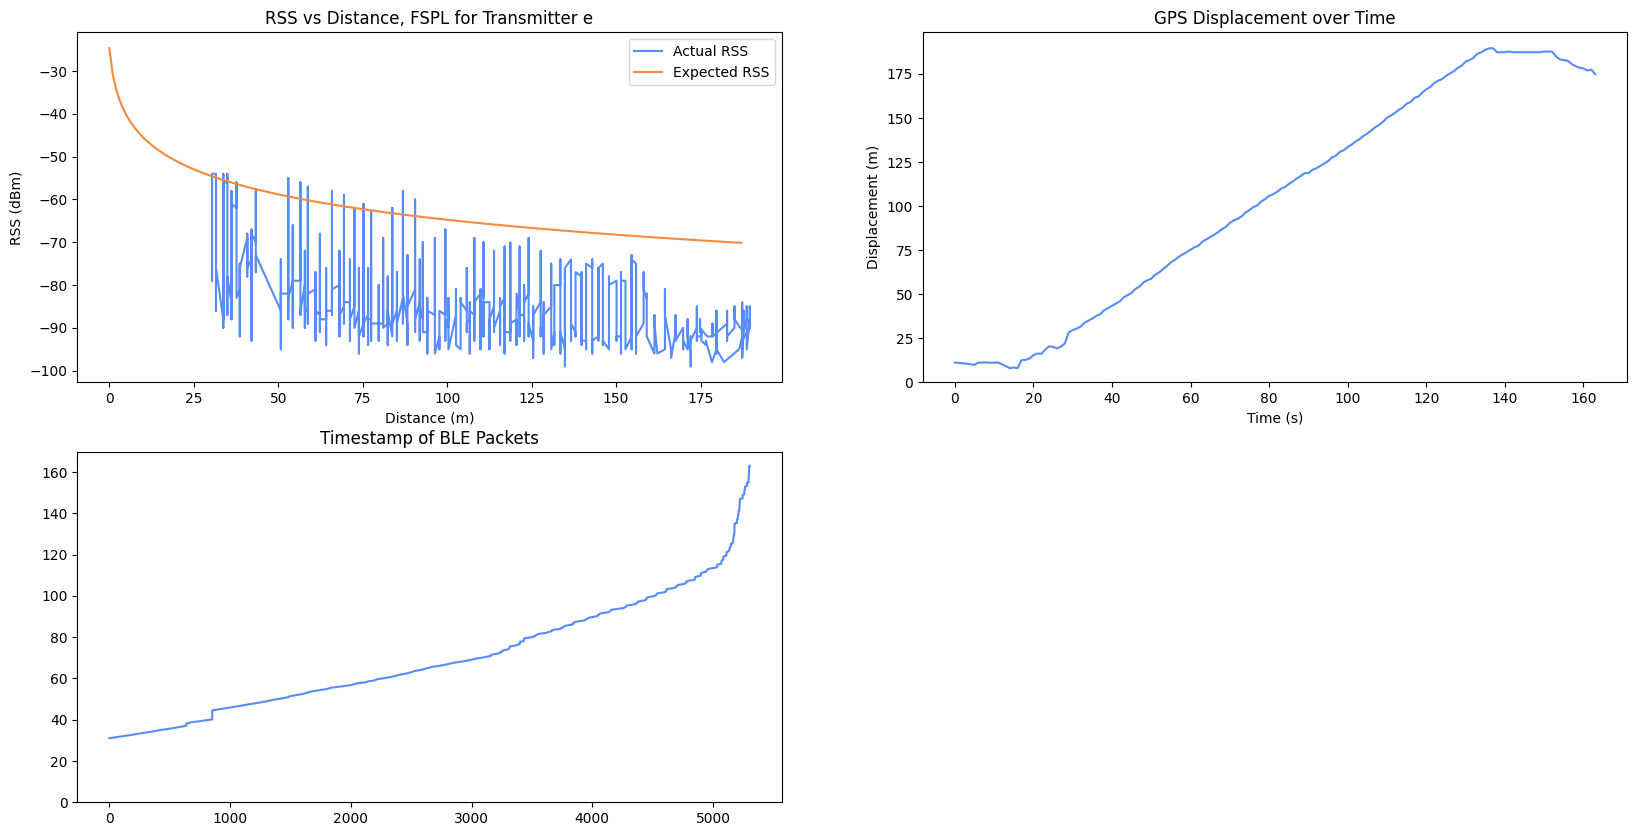

In [6]:
plt.figure(figsize=(20, 10))
plt.subplot(2, 2, 1)
plot_rss_vs_dist_vs_fspl(log_e)

plt.subplot(2, 2, 2)
plot_gps_displacement(log_e.gps_log)

plt.subplot(2, 2, 3)
plt.plot(log_e.all_times())
plt.ylim(bottom=0)
plt.title("Timestamp of BLE Packets")
plt.show()

### Transmitter B

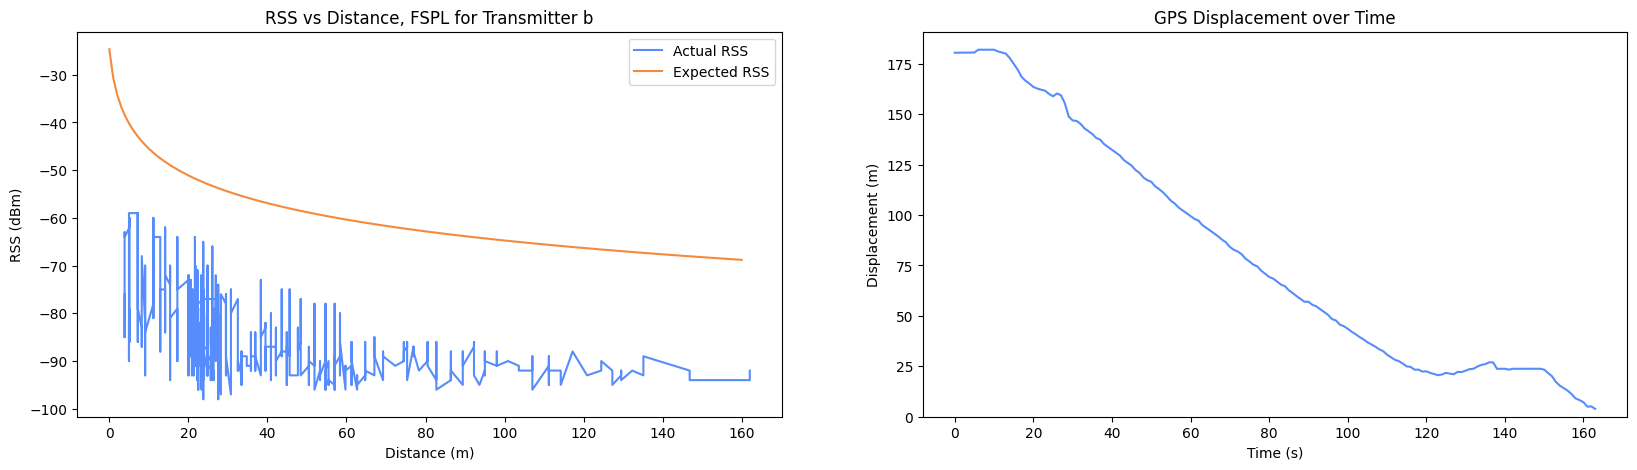

In [7]:
plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1)
plot_rss_vs_dist_vs_fspl(log_b)

plt.subplot(1, 2, 2)
plot_gps_displacement(log_b.gps_log)
plt.show()

### Transmitter C

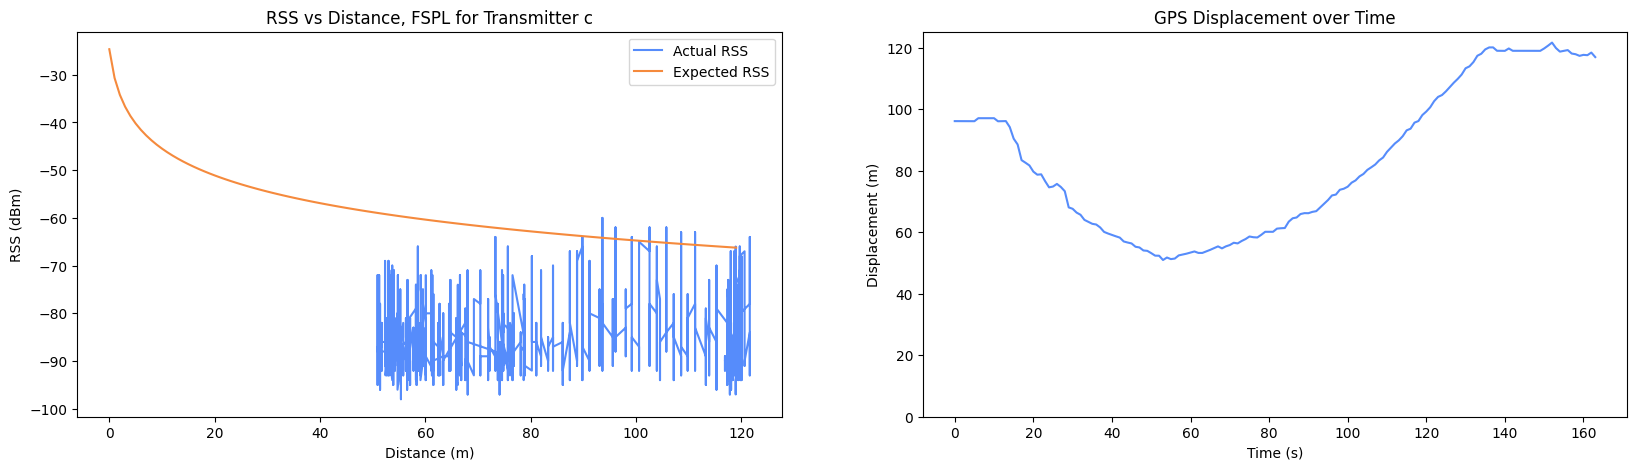

In [8]:
plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1)
plot_rss_vs_dist_vs_fspl(log_c)

plt.subplot(1, 2, 2)
plot_gps_displacement(log_c.gps_log)
plt.show()

### Transmitter A

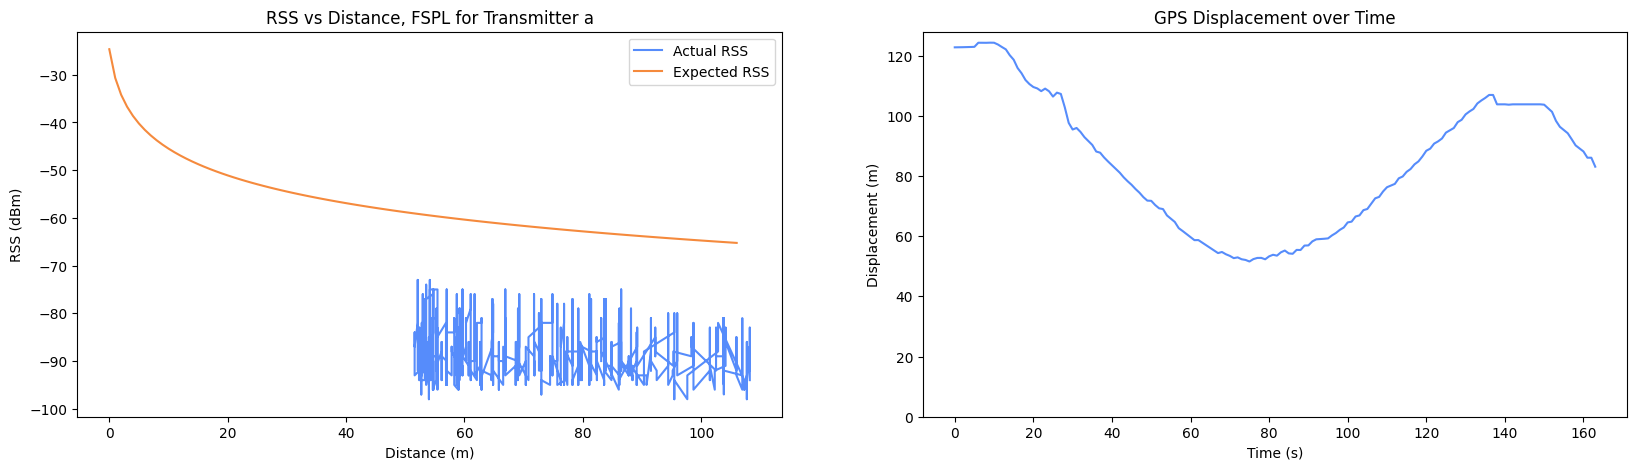

In [9]:
plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1)
plot_rss_vs_dist_vs_fspl(log_a)

plt.subplot(1, 2, 2)
plot_gps_displacement(log_a.gps_log)
plt.show()

## Estimated vs Actual RSS using GPS on March 2025 Experiments

In [10]:
march_file_prefix = "/home/finley/Git/BLEanalysis/bluetooth_experiments/March 26 2025 Field Trial/"

experiments_with_gps = {
    "complexpath7" : "2025-03-26_12_05_30_my_iOS_device.csv",
    "complexpath8" : "2025-03-26_12_09_13_my_iOS_device.csv",
    "complexpath9" : "2025-03-26_12_13_54_my_iOS_device.csv",
    "complexpath10" : "2025-03-26_12_19_59_my_iOS_device.csv",
    "complexpath11" : "2025-03-26_12_25_20_my_iOS_device.csv",
    "straightpath1" : "2025-03-26_11_37_00_my_iOS_device.csv",
    "straightpath2" : "2025-03-26_11_39_32_my_iOS_device.csv",
    "straightpath3" : "2025-03-26_11_42_42_my_iOS_device.csv",
    "straightpath4" : "2025-03-26_11_46_43_my_iOS_device.csv",
    "straightpath5" : "2025-03-26_11_50_22_my_iOS_device.csv",
    "straightpath6" : "2025-03-26_11_54_32_my_iOS_device.csv"
}

logs_with_names: dict[str, list[BleLog]] = {}

for folder, gps_file in experiments_with_gps.items():
    print(f"Processing {folder}")
    gps_log = GpsLog(march_file_prefix + folder + "/" + gps_file)
    logs_with_names[folder] = []

    for tx in [tx_a, tx_b, tx_c, tx_e]:
        ble_log = BleLog(march_file_prefix + folder + f"/{folder}.log", tx, deepcopy(gps_log))
        logs_with_names[folder].append(ble_log)

Processing complexpath7
GpsLog | no. points: 171, time: 170.001
BleLog | tx: a, no.packets: 4667, time: 170.001s
BleLog | tx: b, no.packets: 6033, time: 170.001s
BleLog | tx: c, no.packets: 11739, time: 170.001s
BleLog | tx: e, no.packets: 2690, time: 170.001s
Processing complexpath8
GpsLog | no. points: 190, time: 189.001
BleLog | tx: a, no.packets: 6332, time: 189.001s
BleLog | tx: b, no.packets: 8030, time: 189.001s
BleLog | tx: c, no.packets: 9301, time: 189.001s
BleLog | tx: e, no.packets: 5877, time: 189.001s
Processing complexpath9
GpsLog | no. points: 220, time: 219.001
BleLog | tx: a, no.packets: 8430, time: 219.001s
BleLog | tx: b, no.packets: 3743, time: 219.001s
BleLog | tx: c, no.packets: 14221, time: 219.001s
BleLog | tx: e, no.packets: 7329, time: 219.001s
Processing complexpath10
GpsLog | no. points: 211, time: 210.001
BleLog | tx: a, no.packets: 8150, time: 210.001s
BleLog | tx: b, no.packets: 5172, time: 210.001s
BleLog | tx: c, no.packets: 12910, time: 210.001s
BleLo

### complexpath7

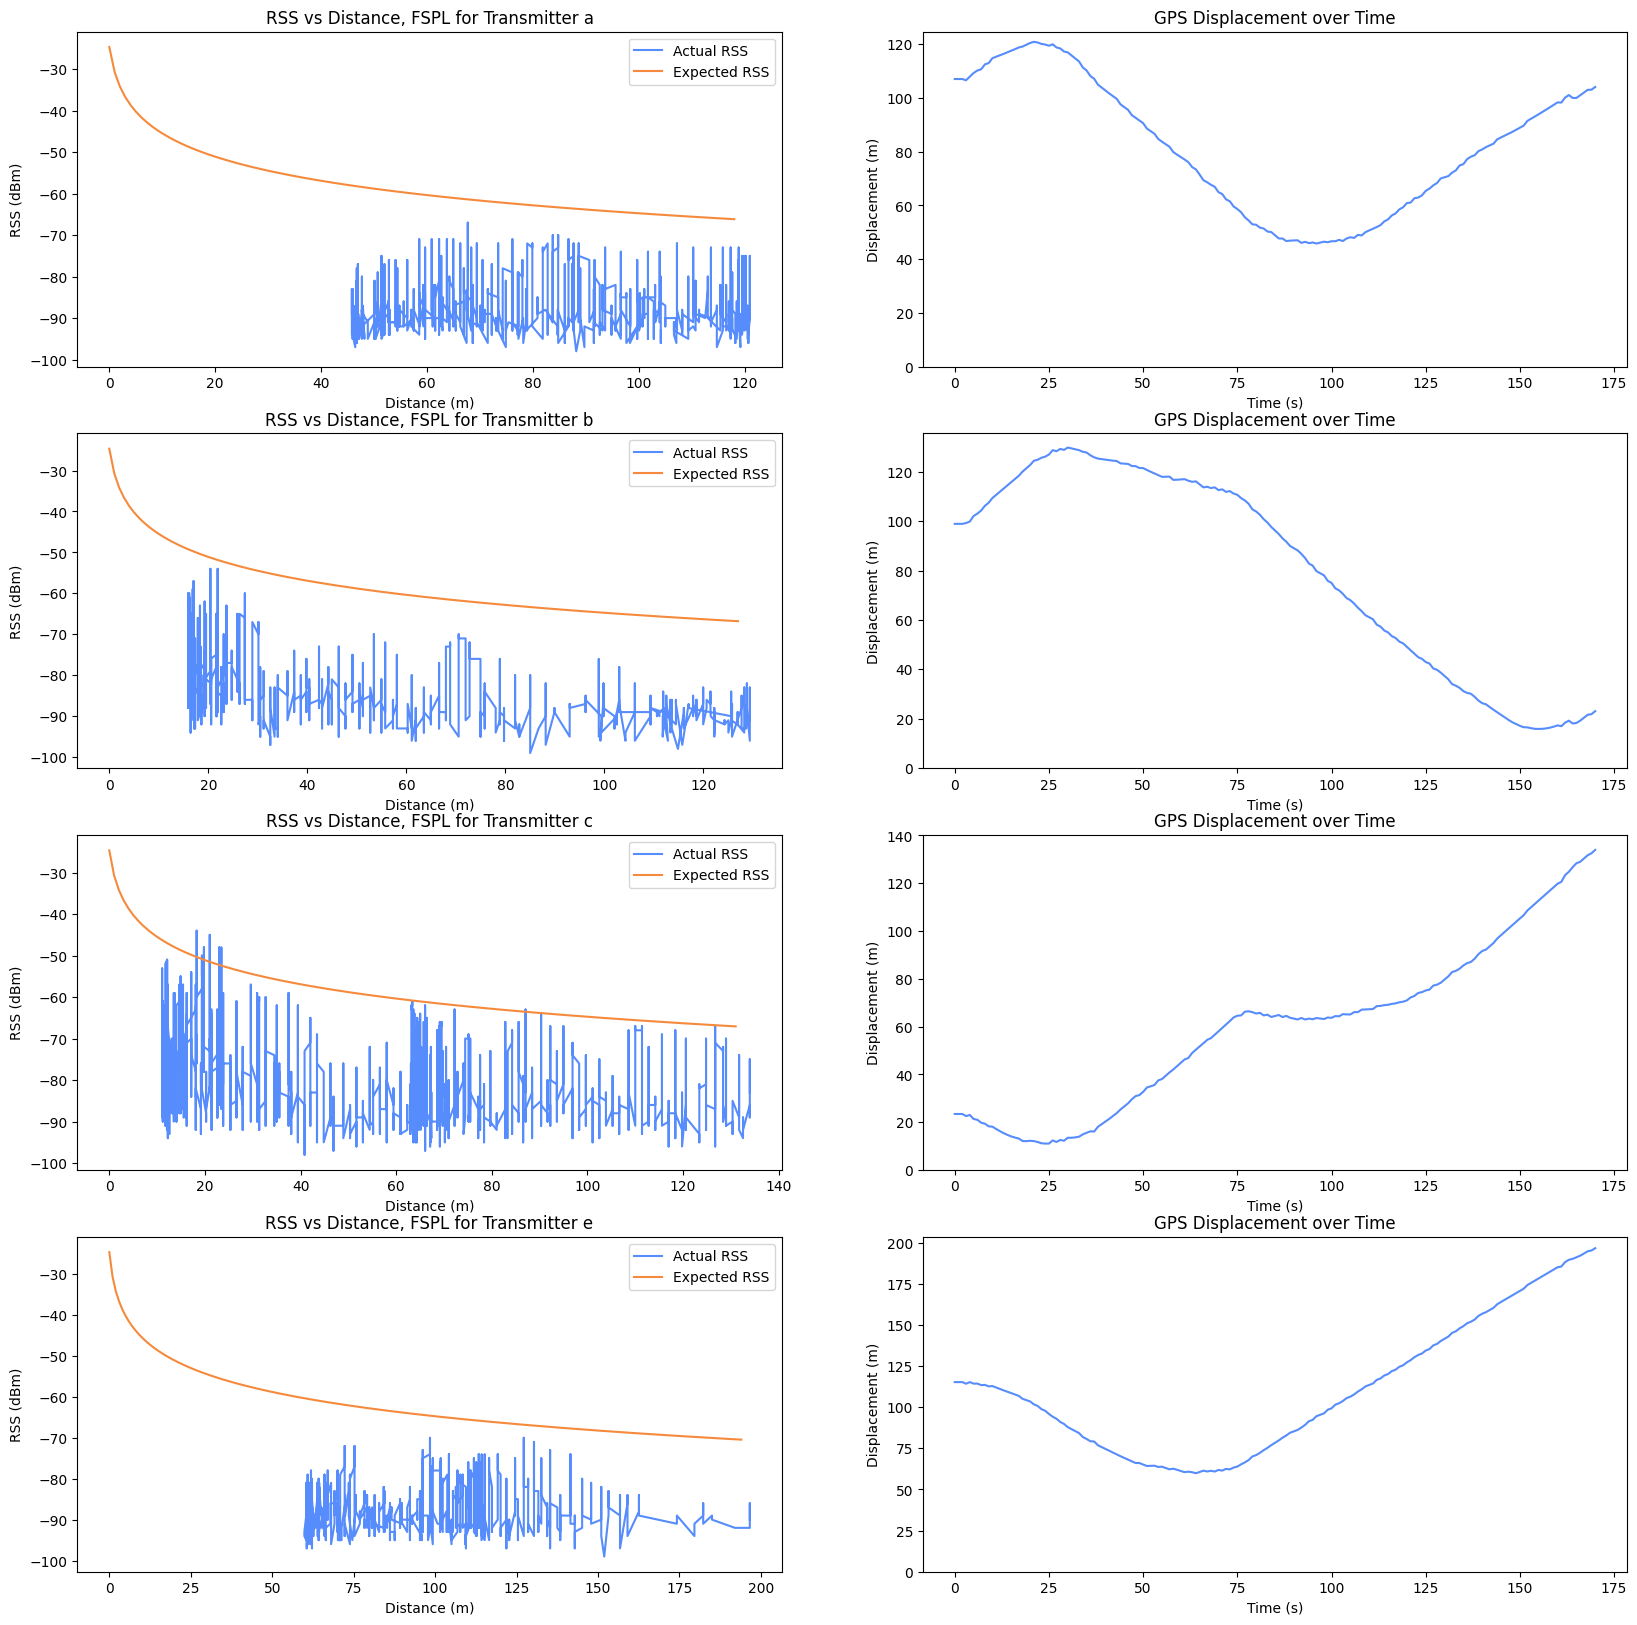

### complexpath8

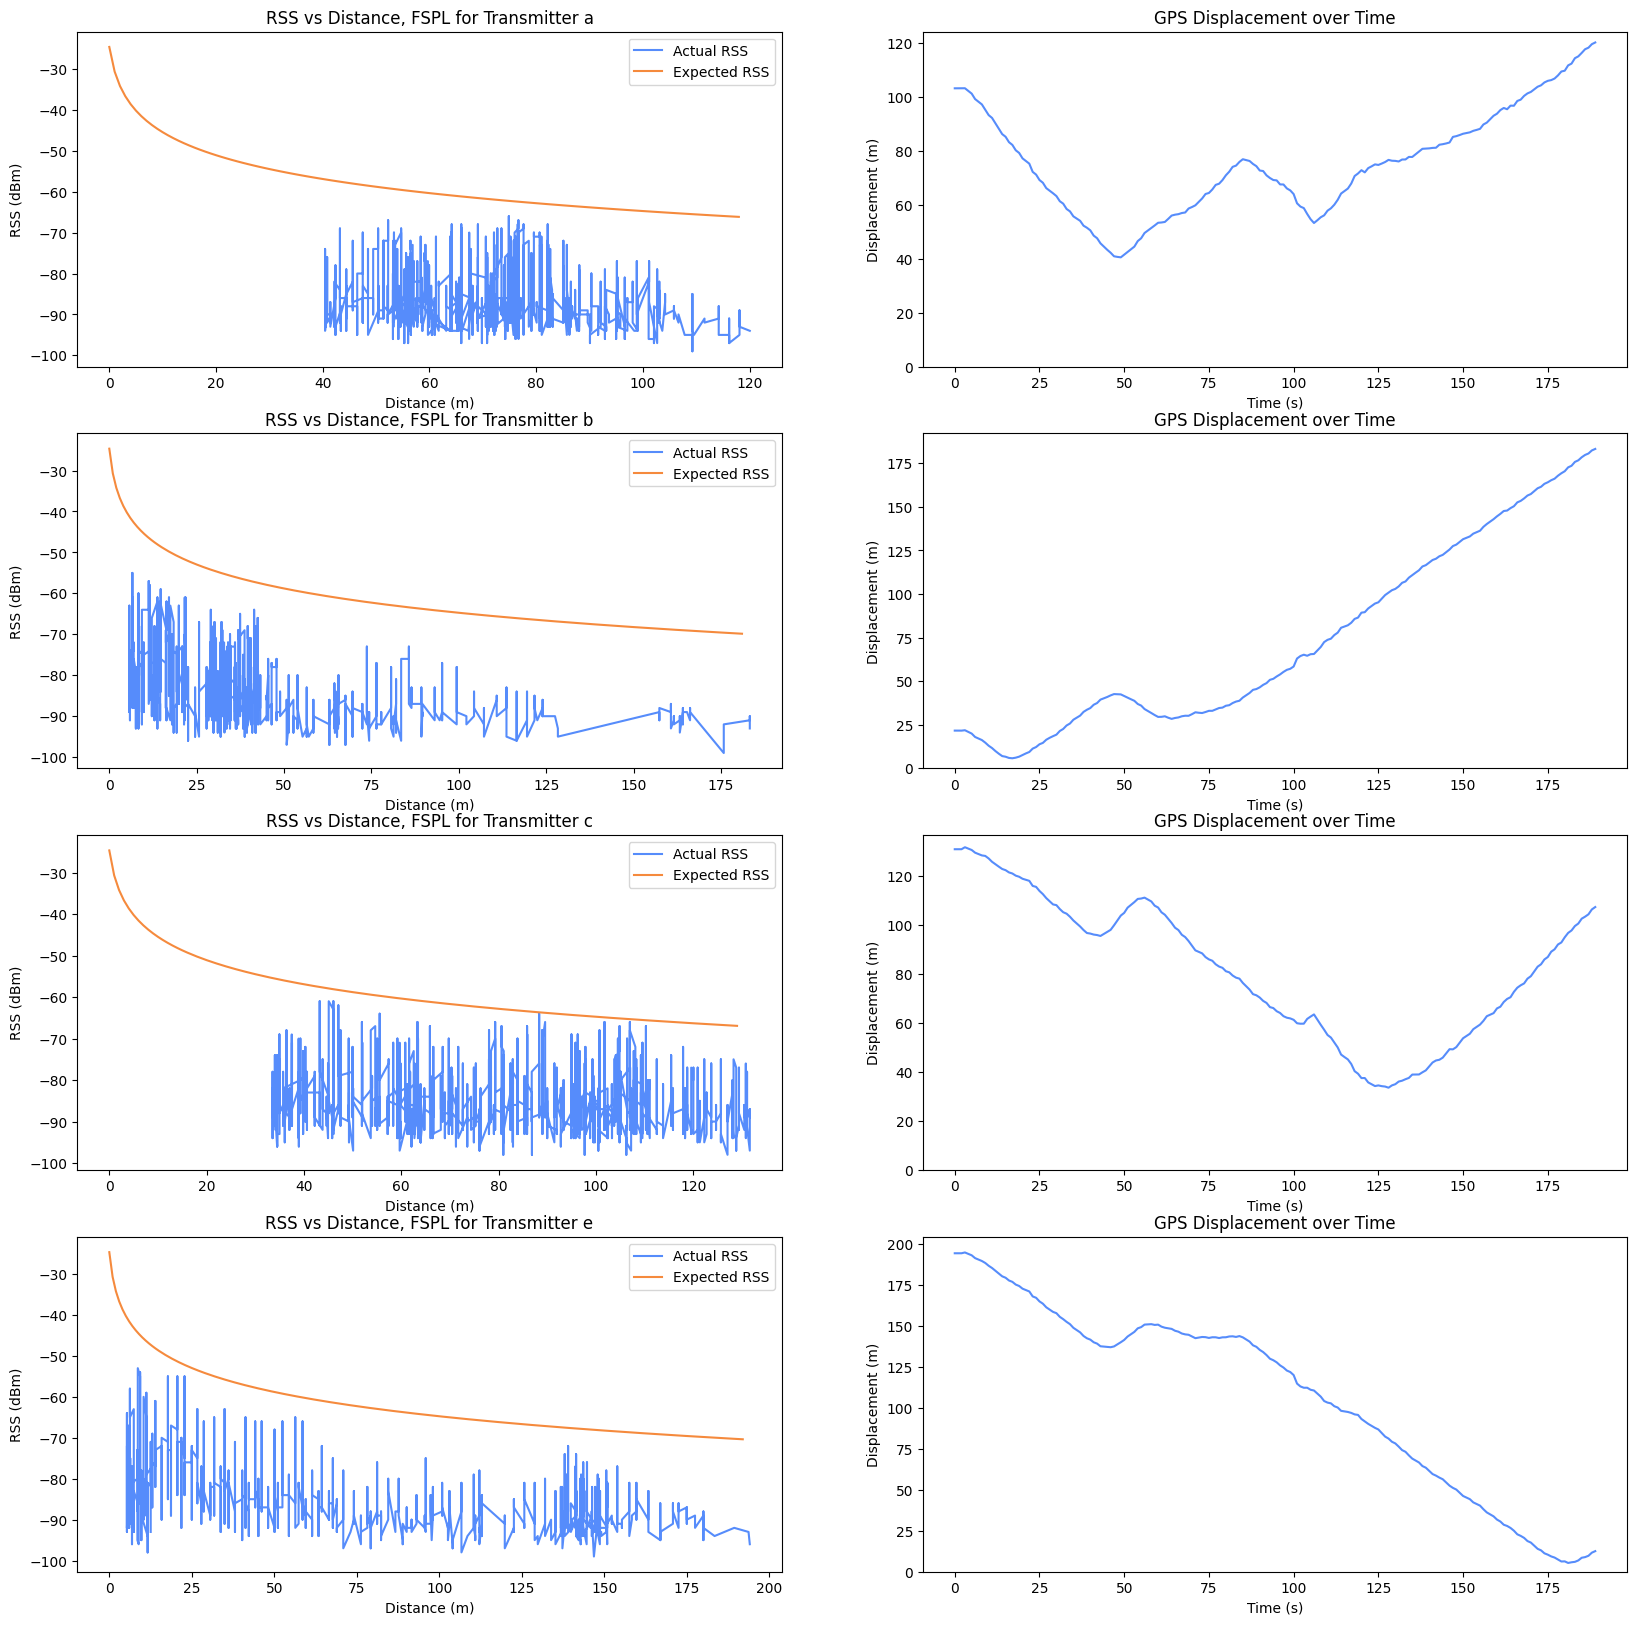

### complexpath9

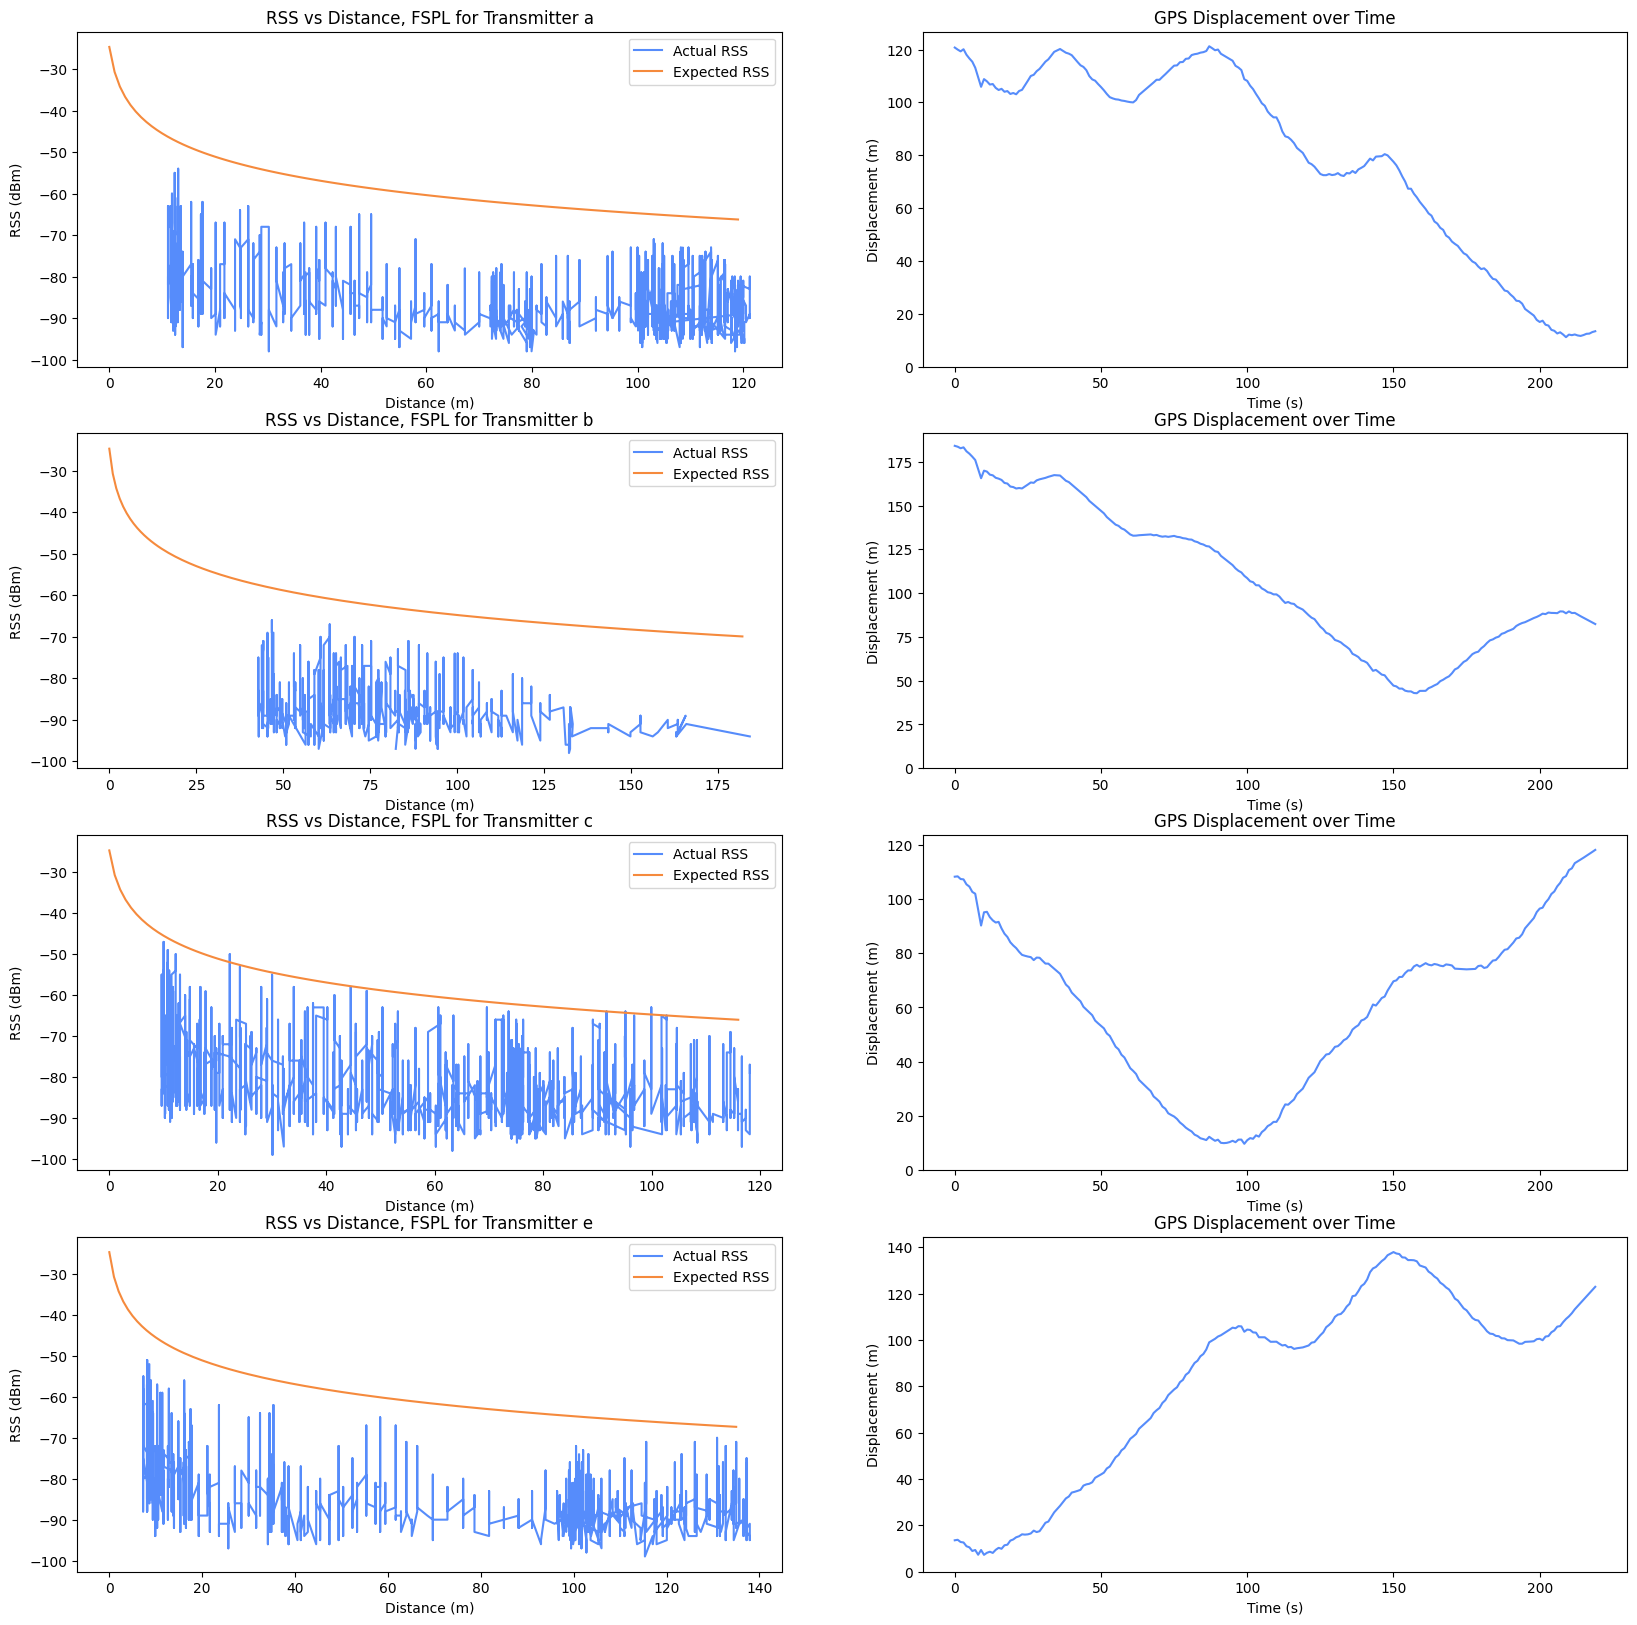

### complexpath10

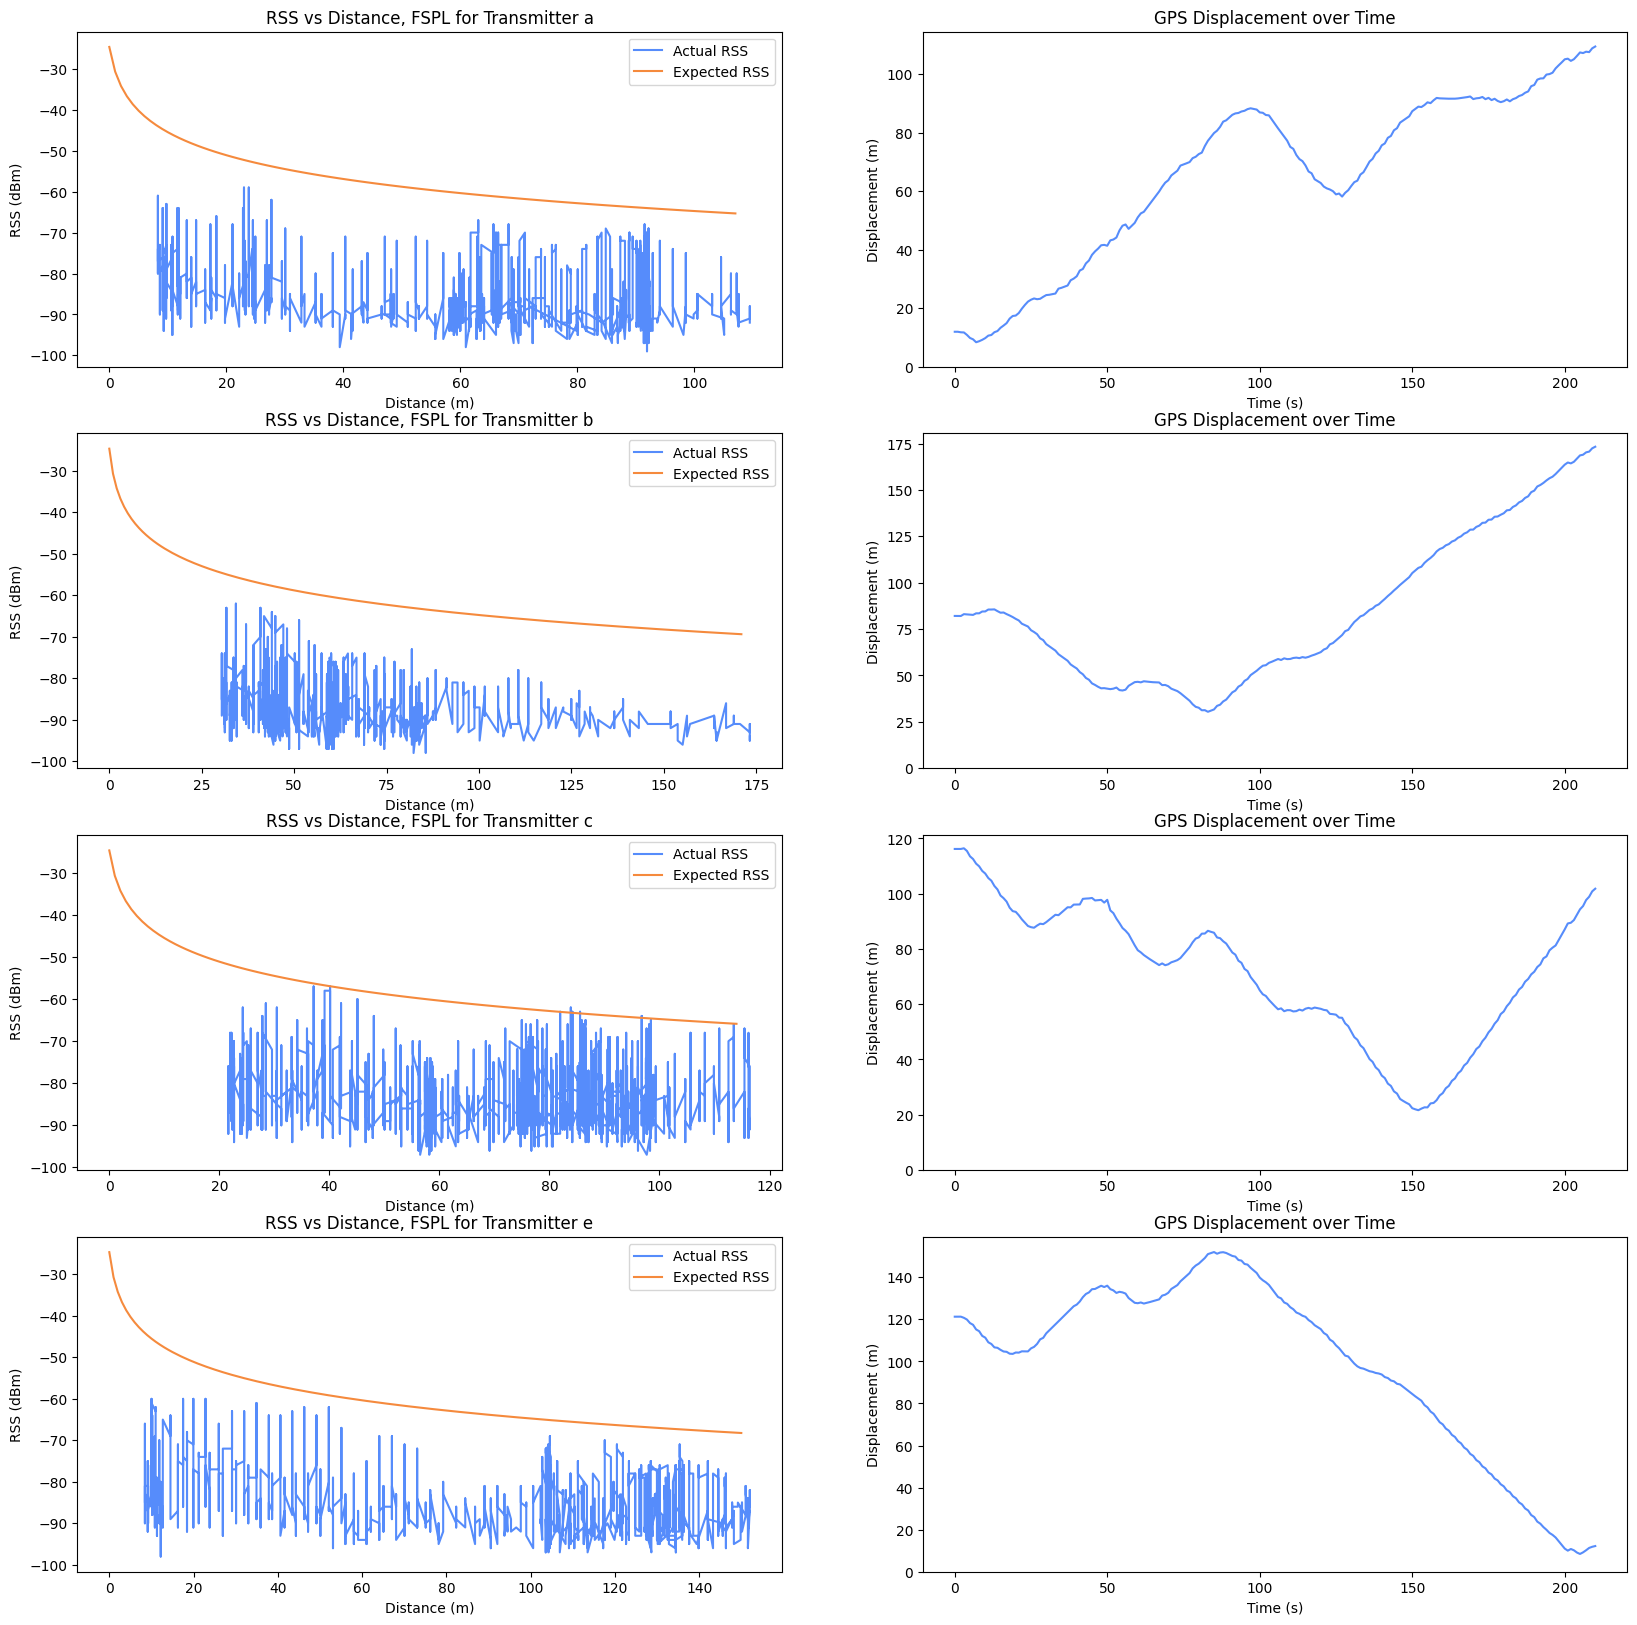

### complexpath11

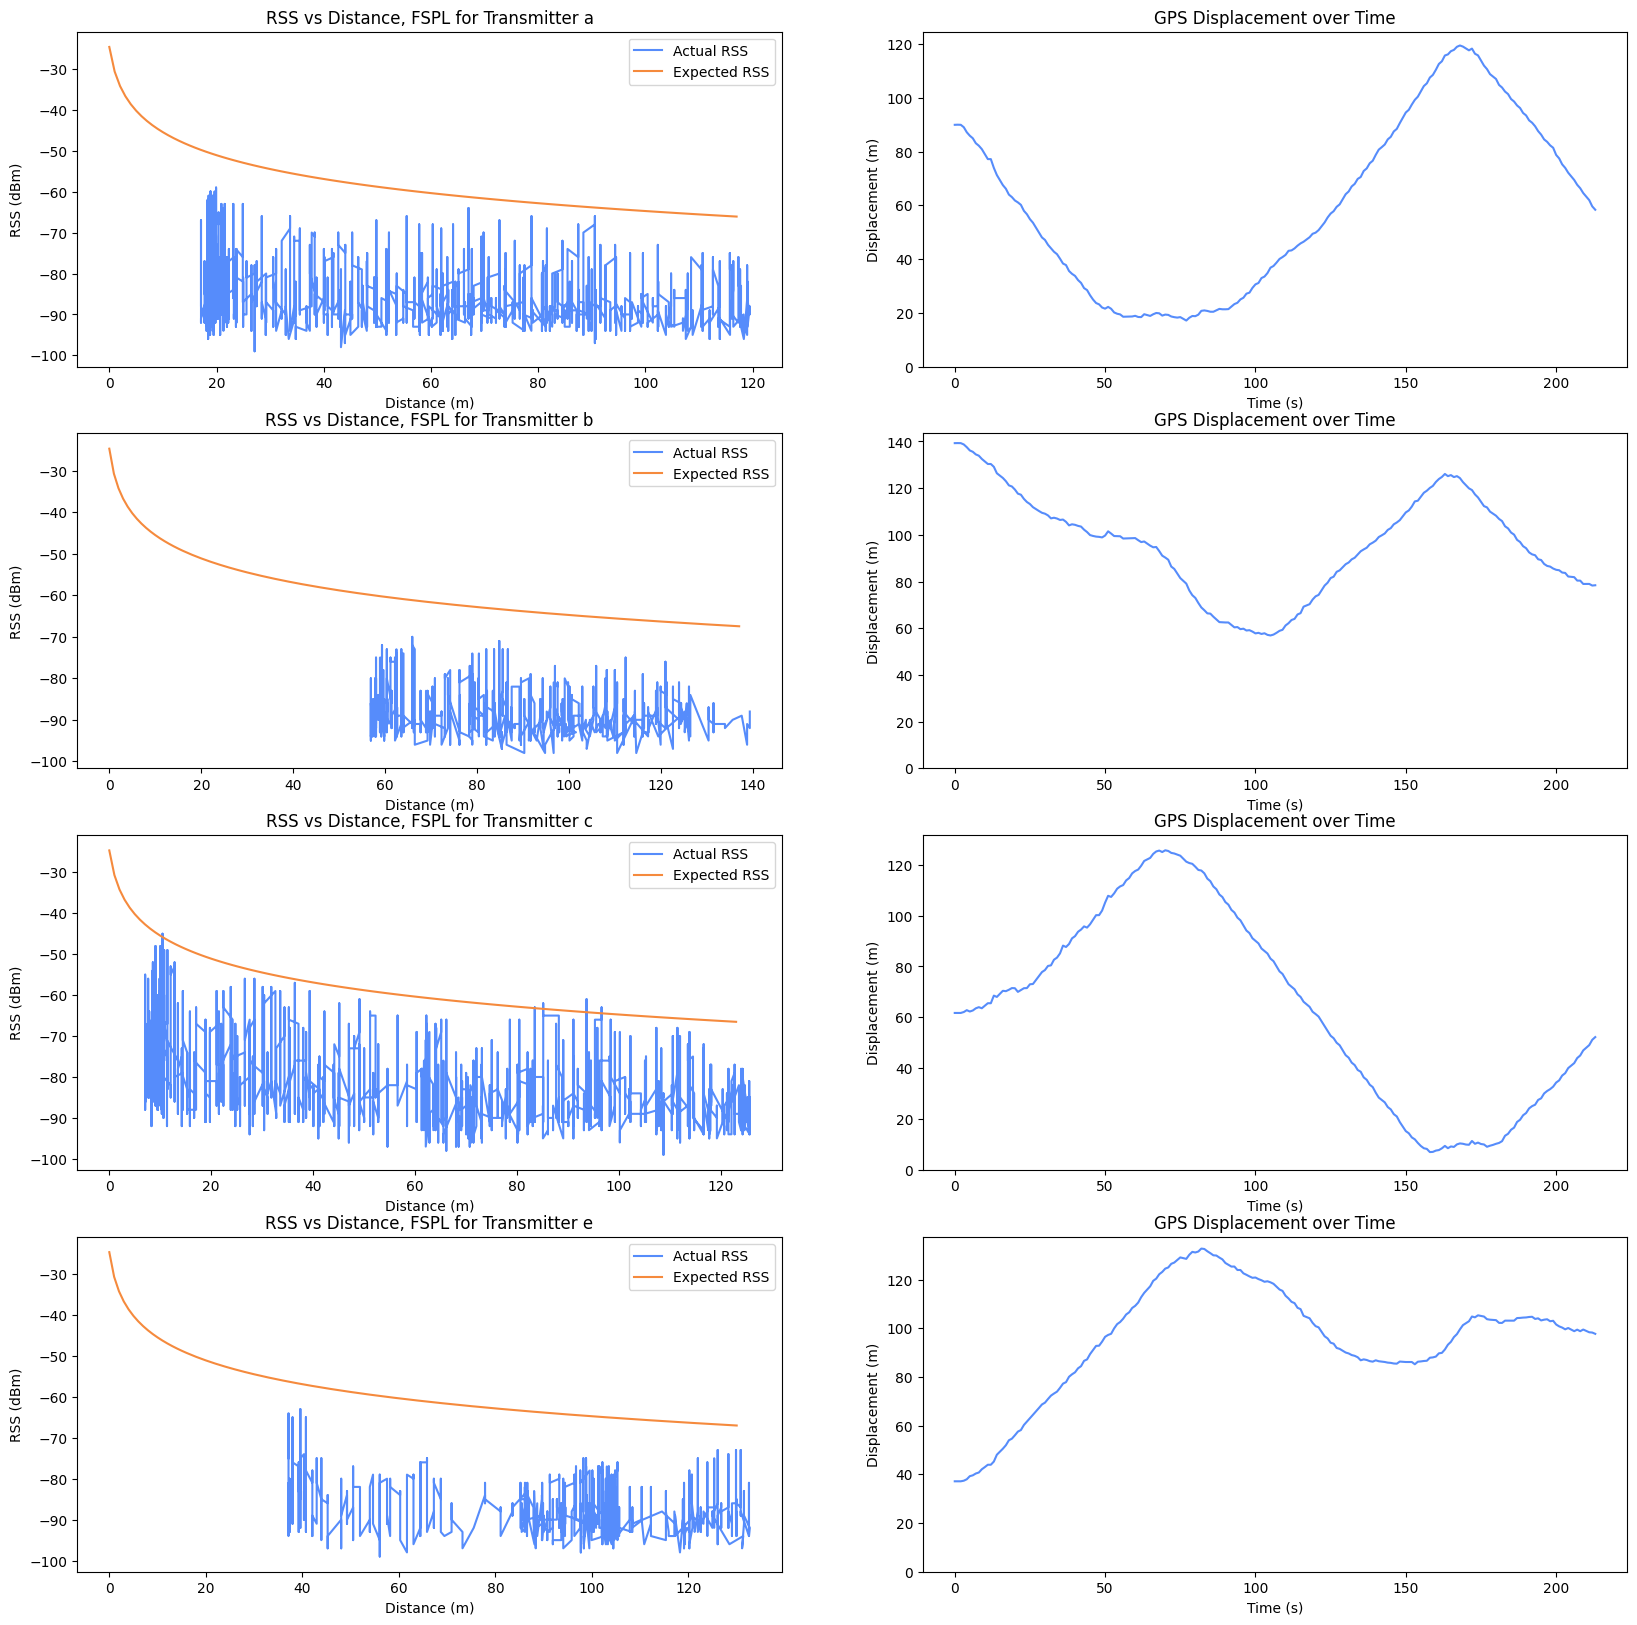

### straightpath1

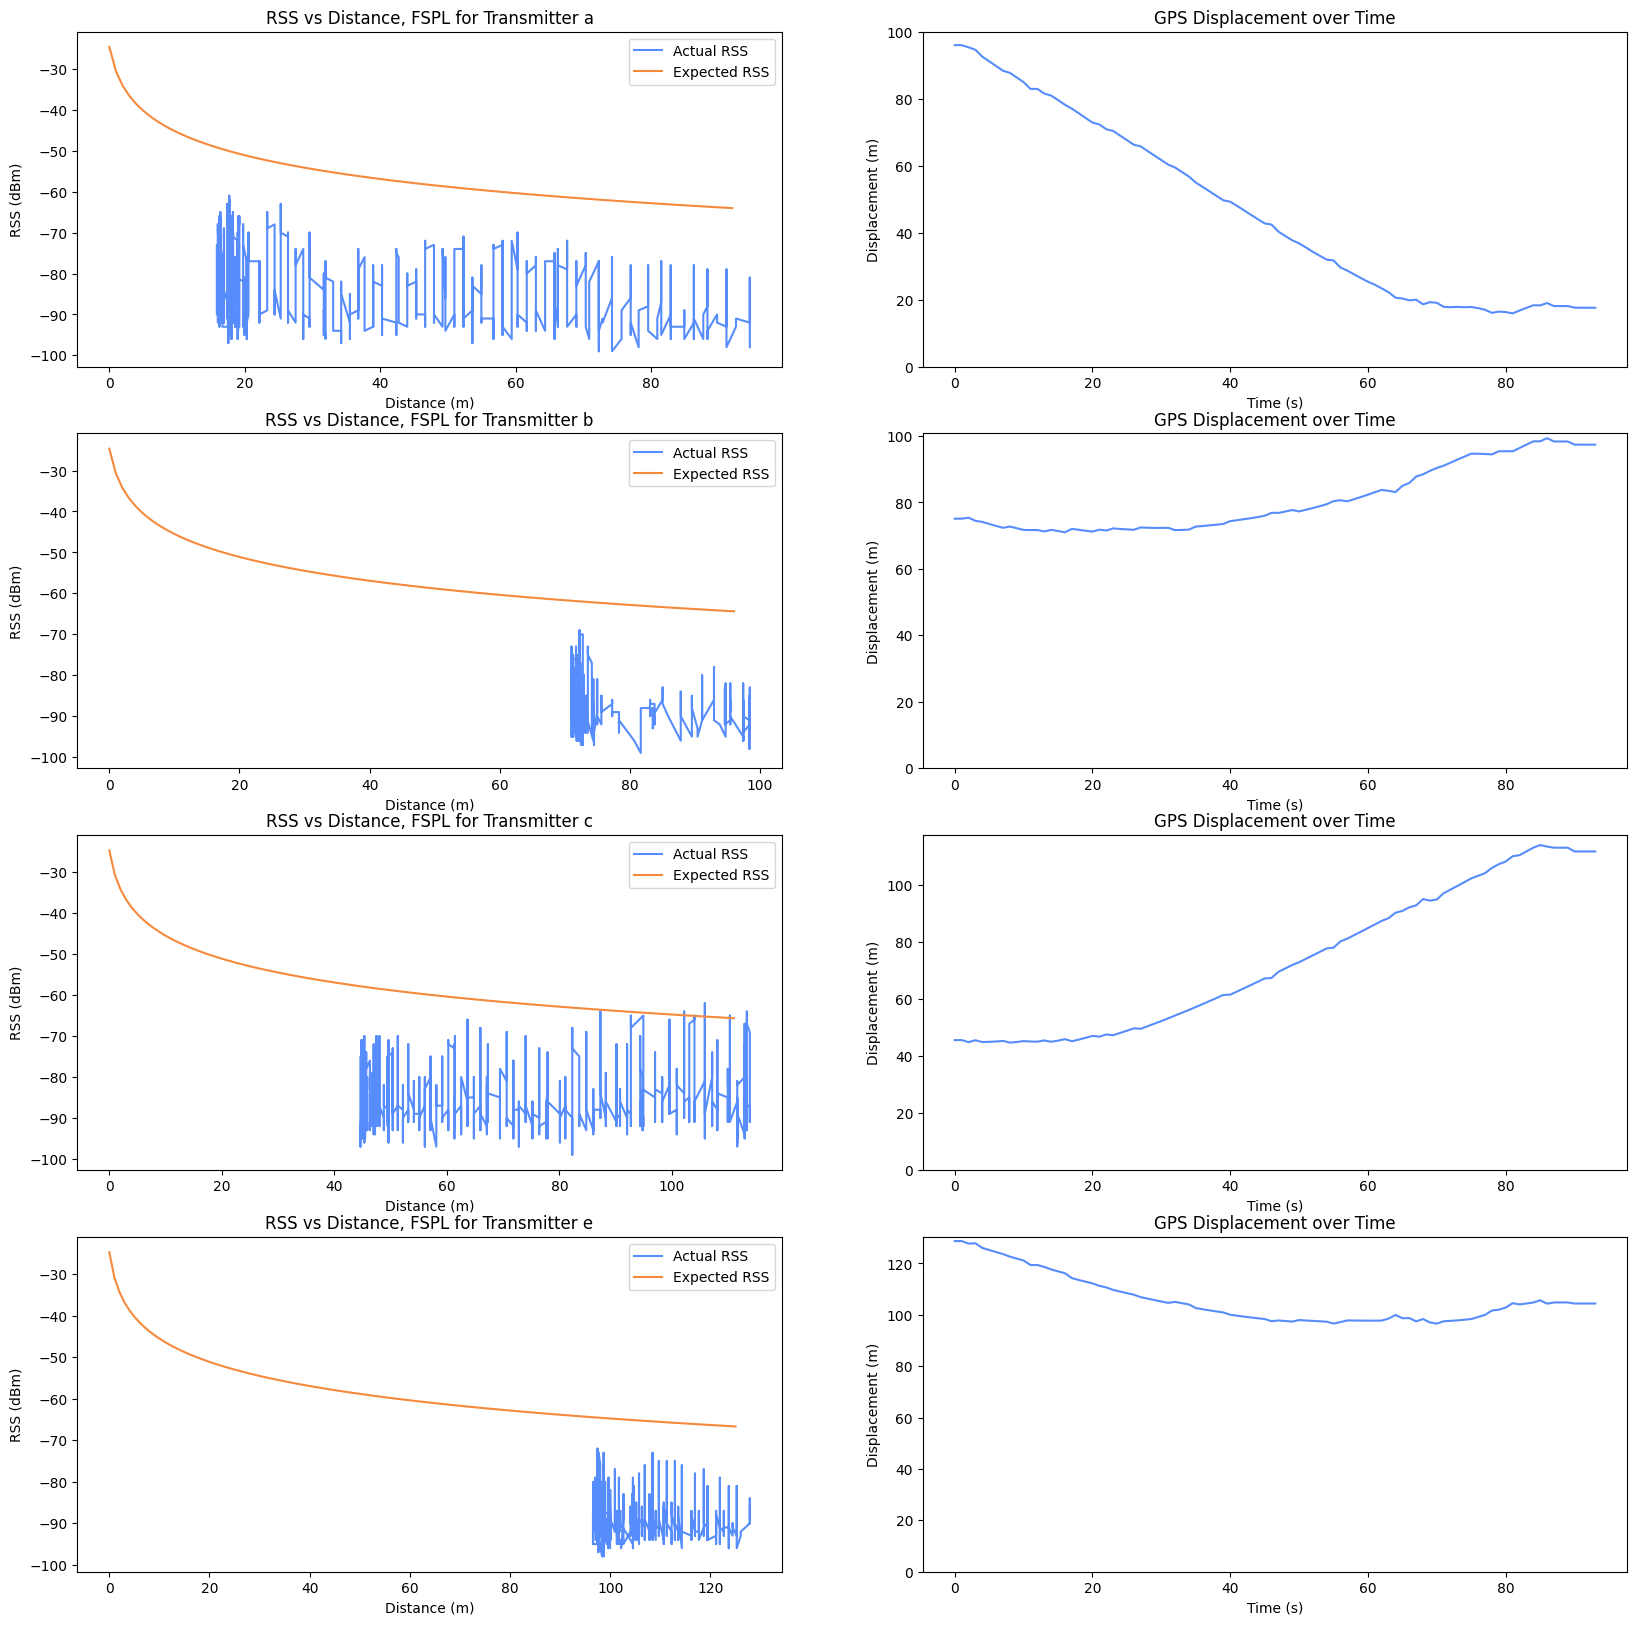

### straightpath2

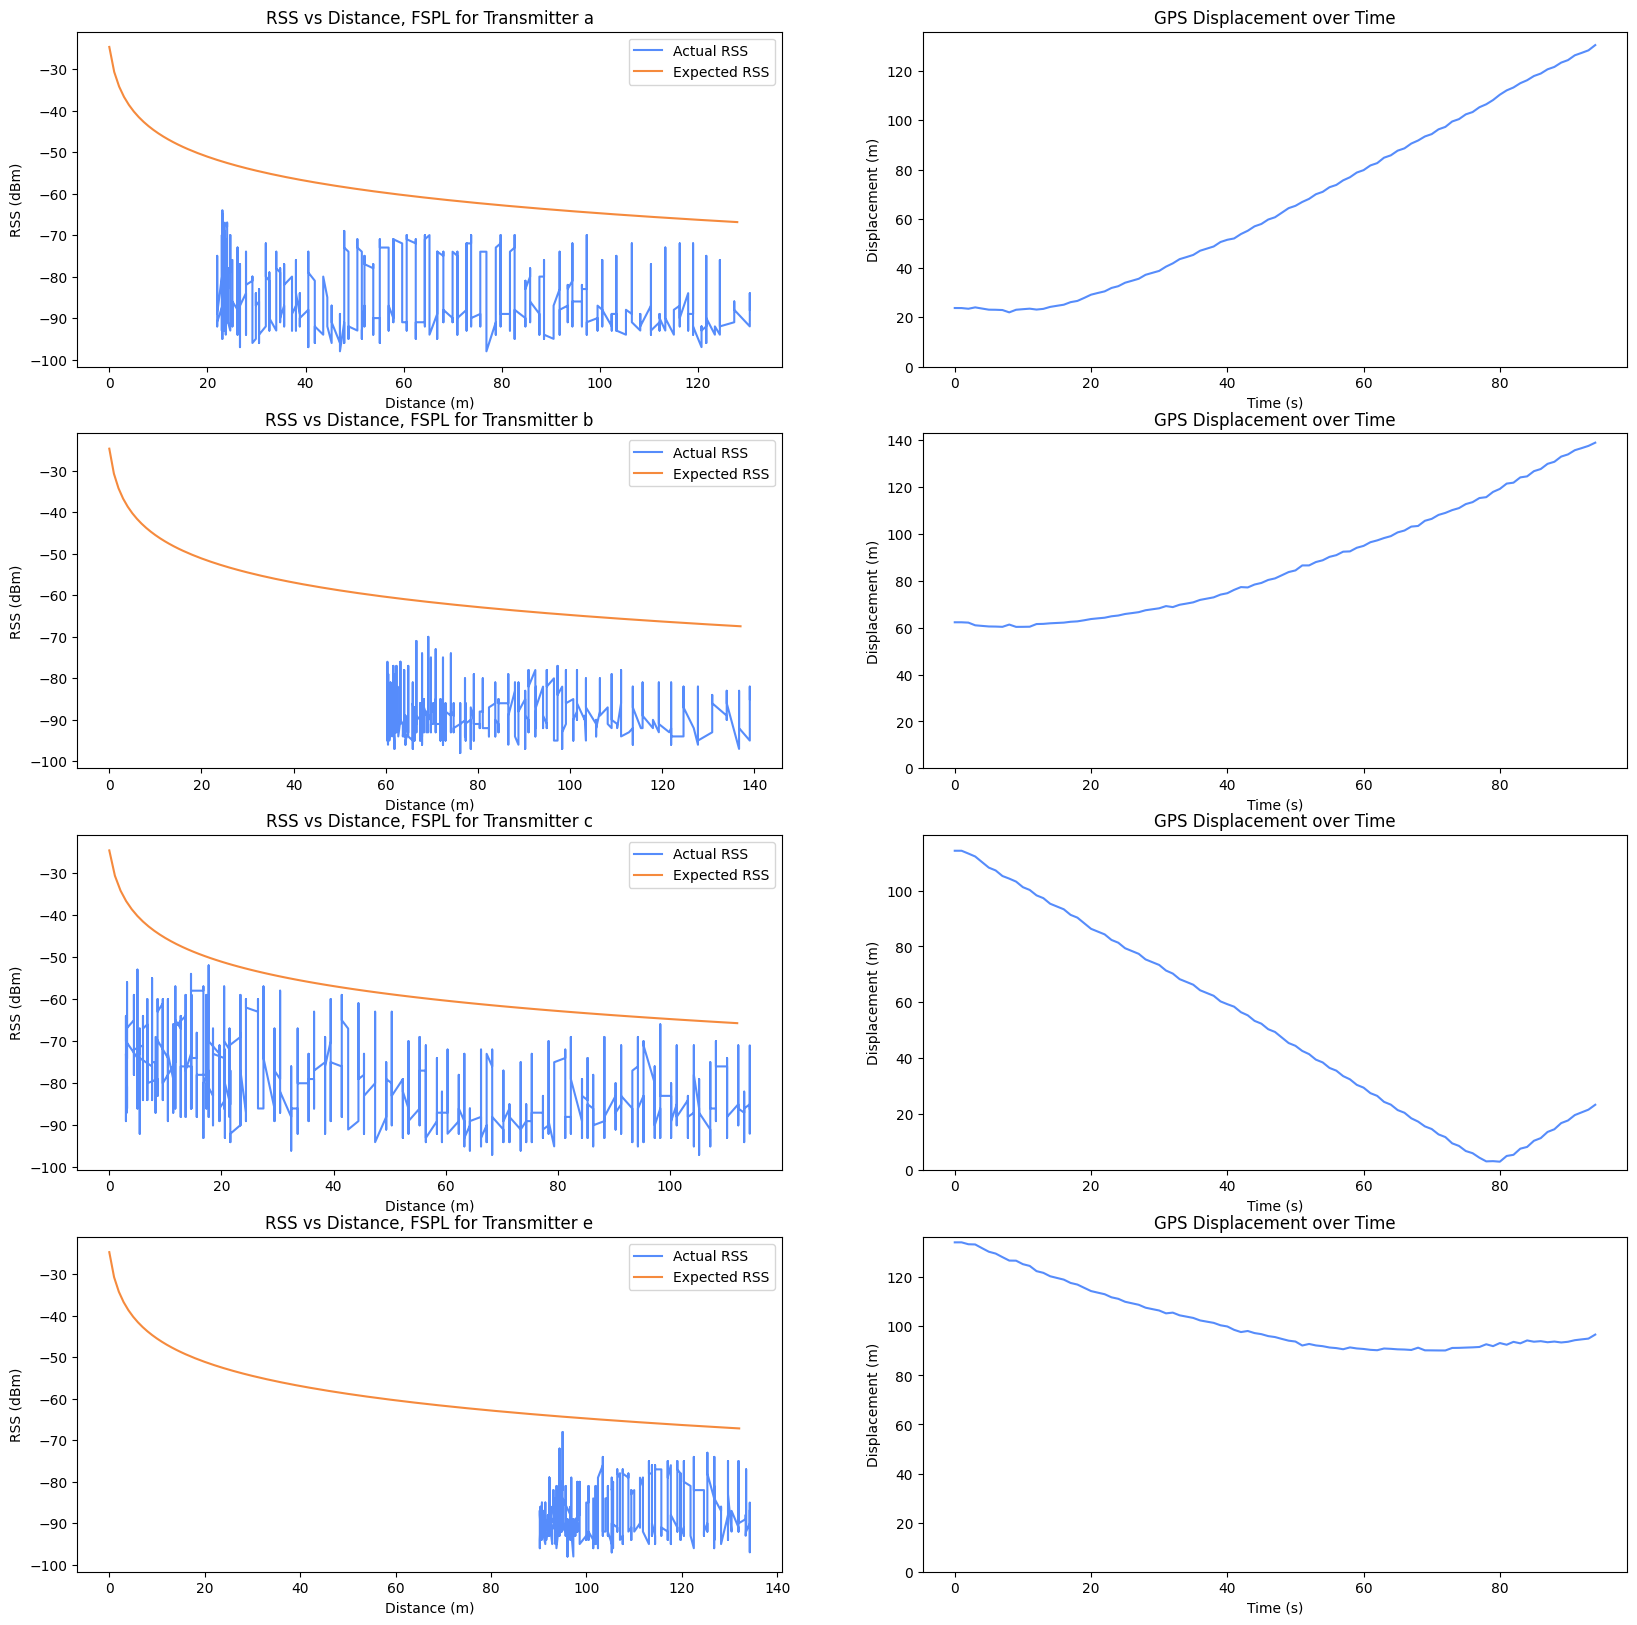

### straightpath3

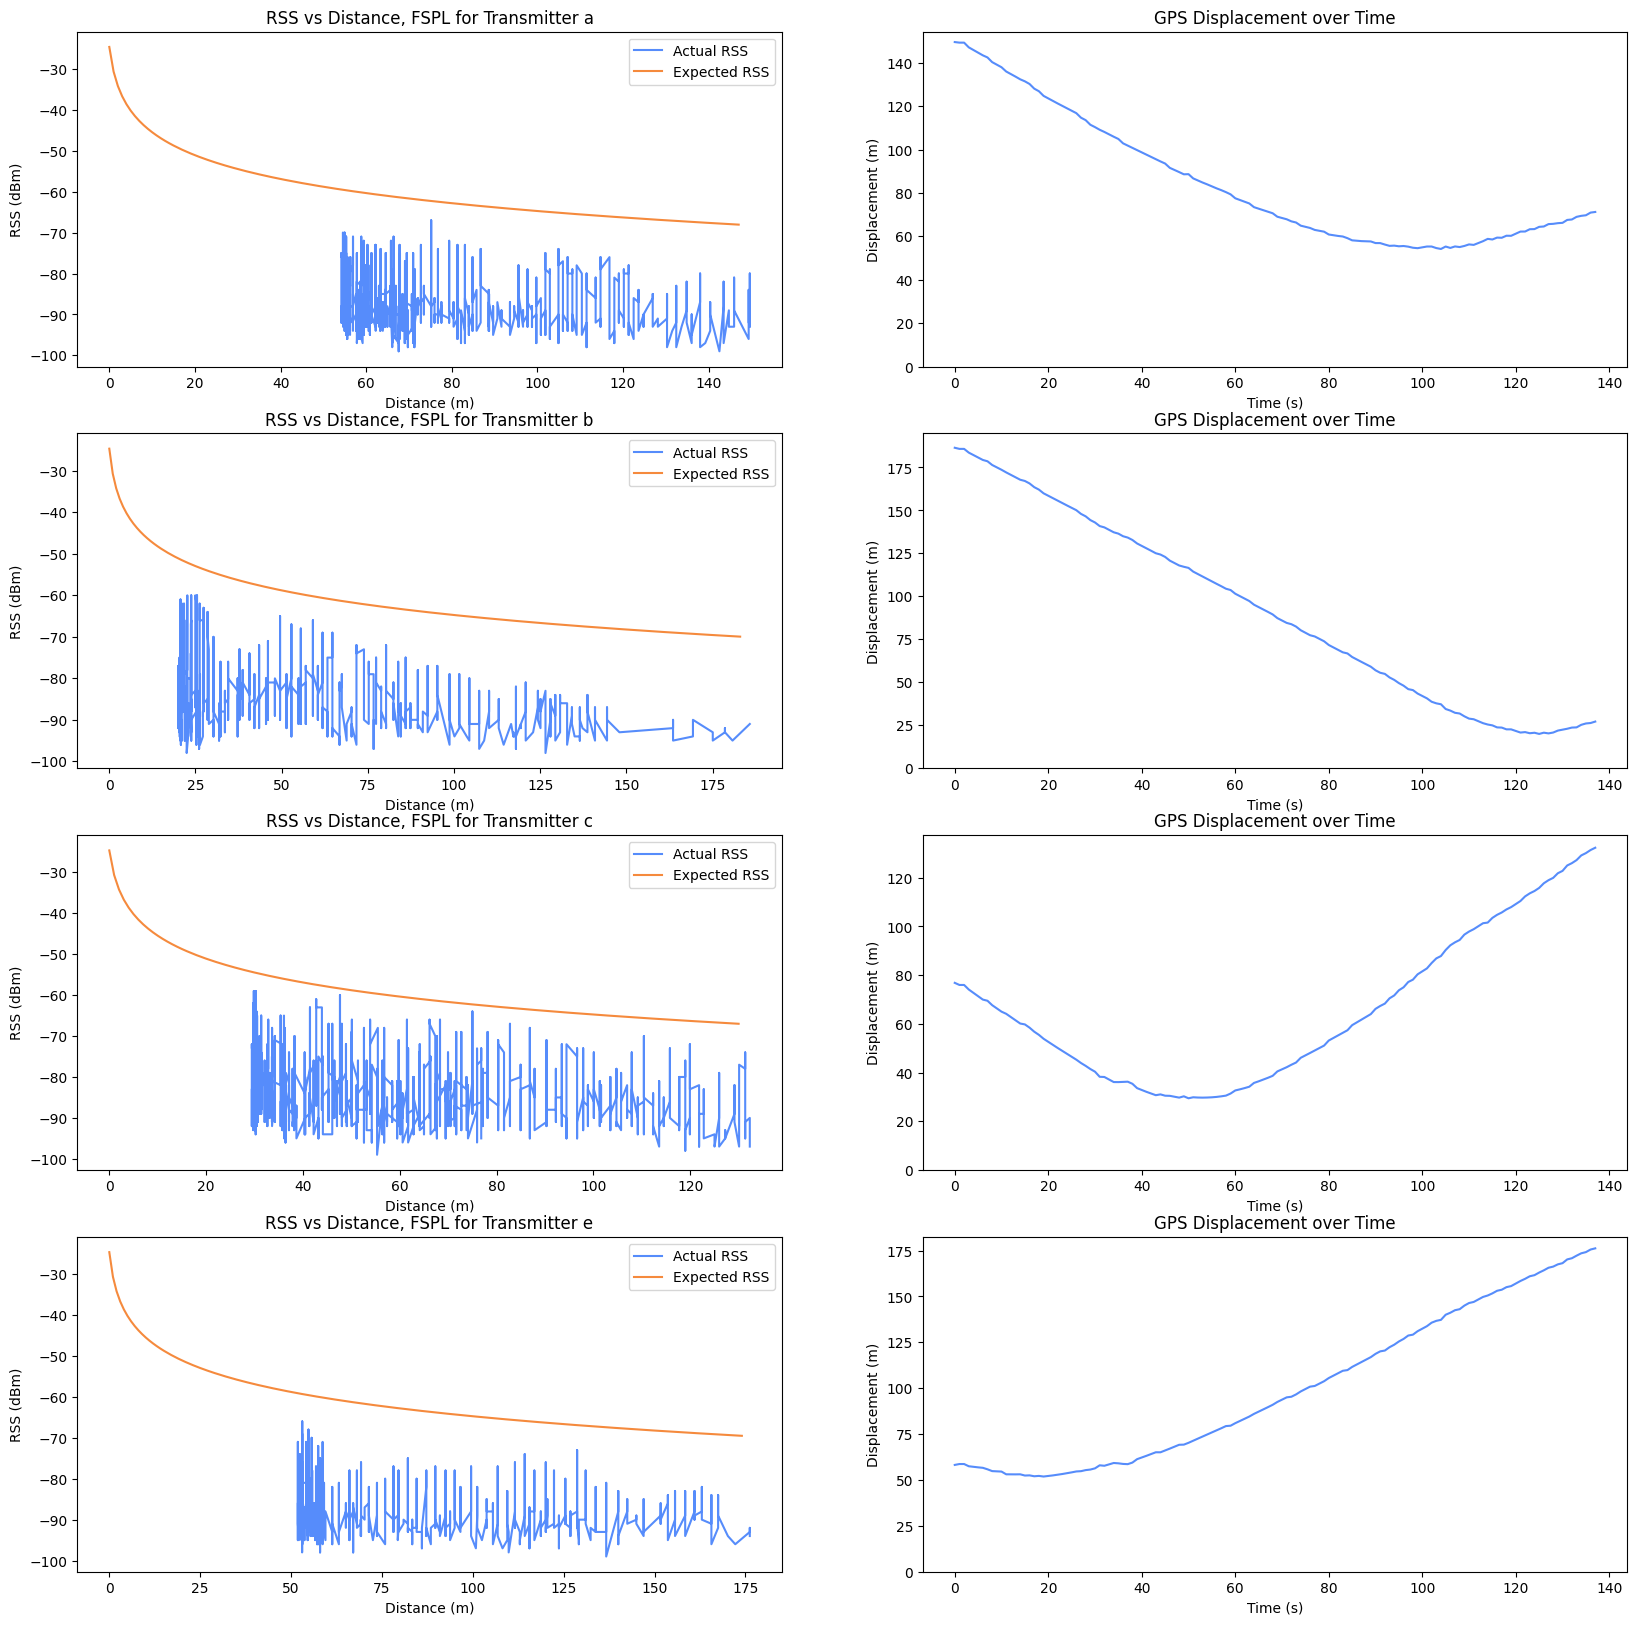

### straightpath4

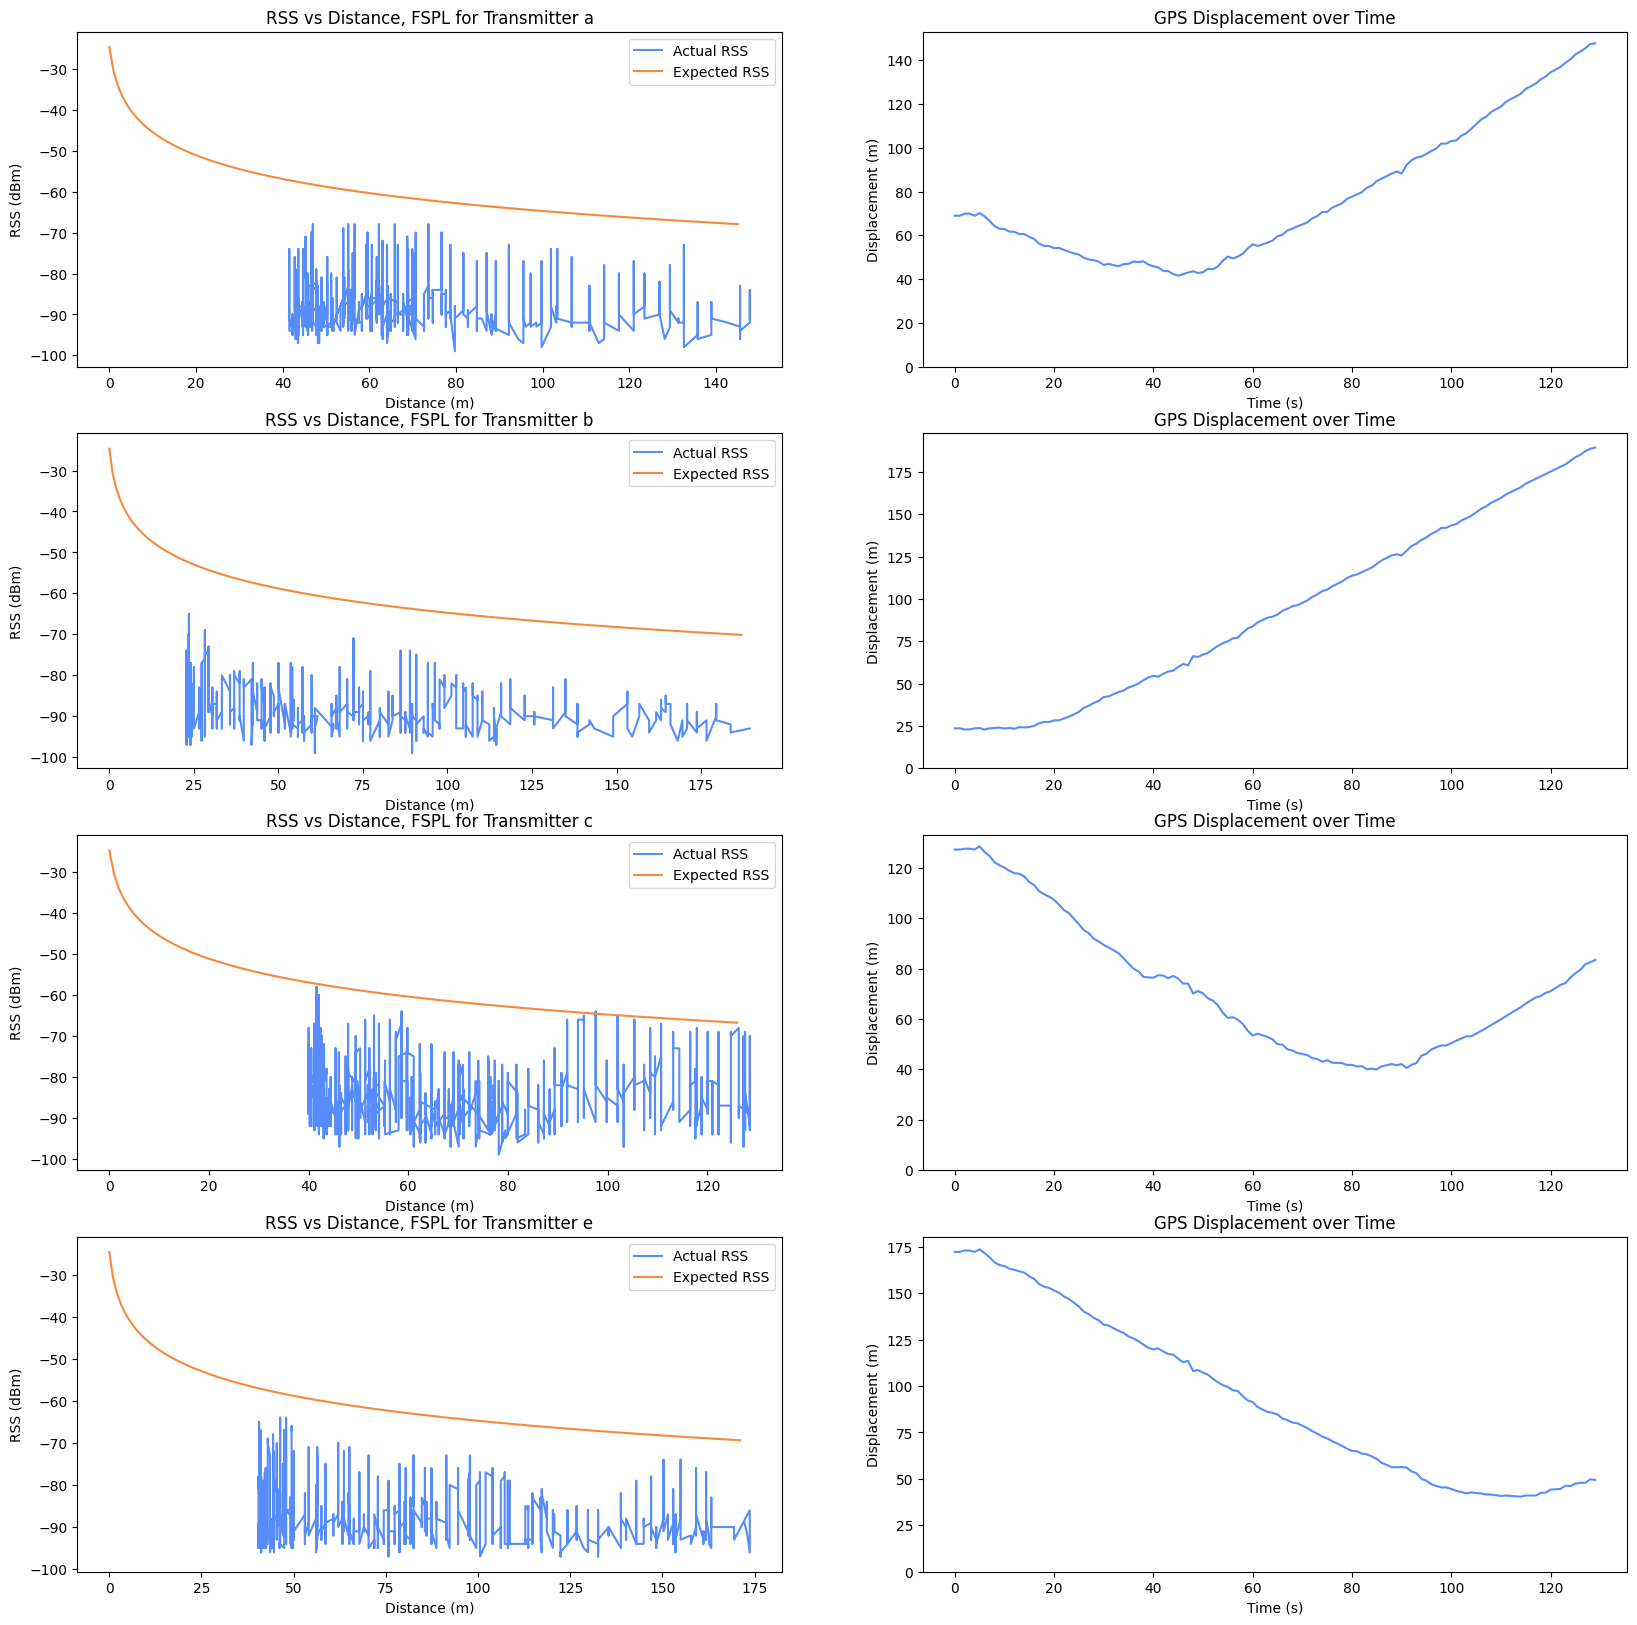

### straightpath5

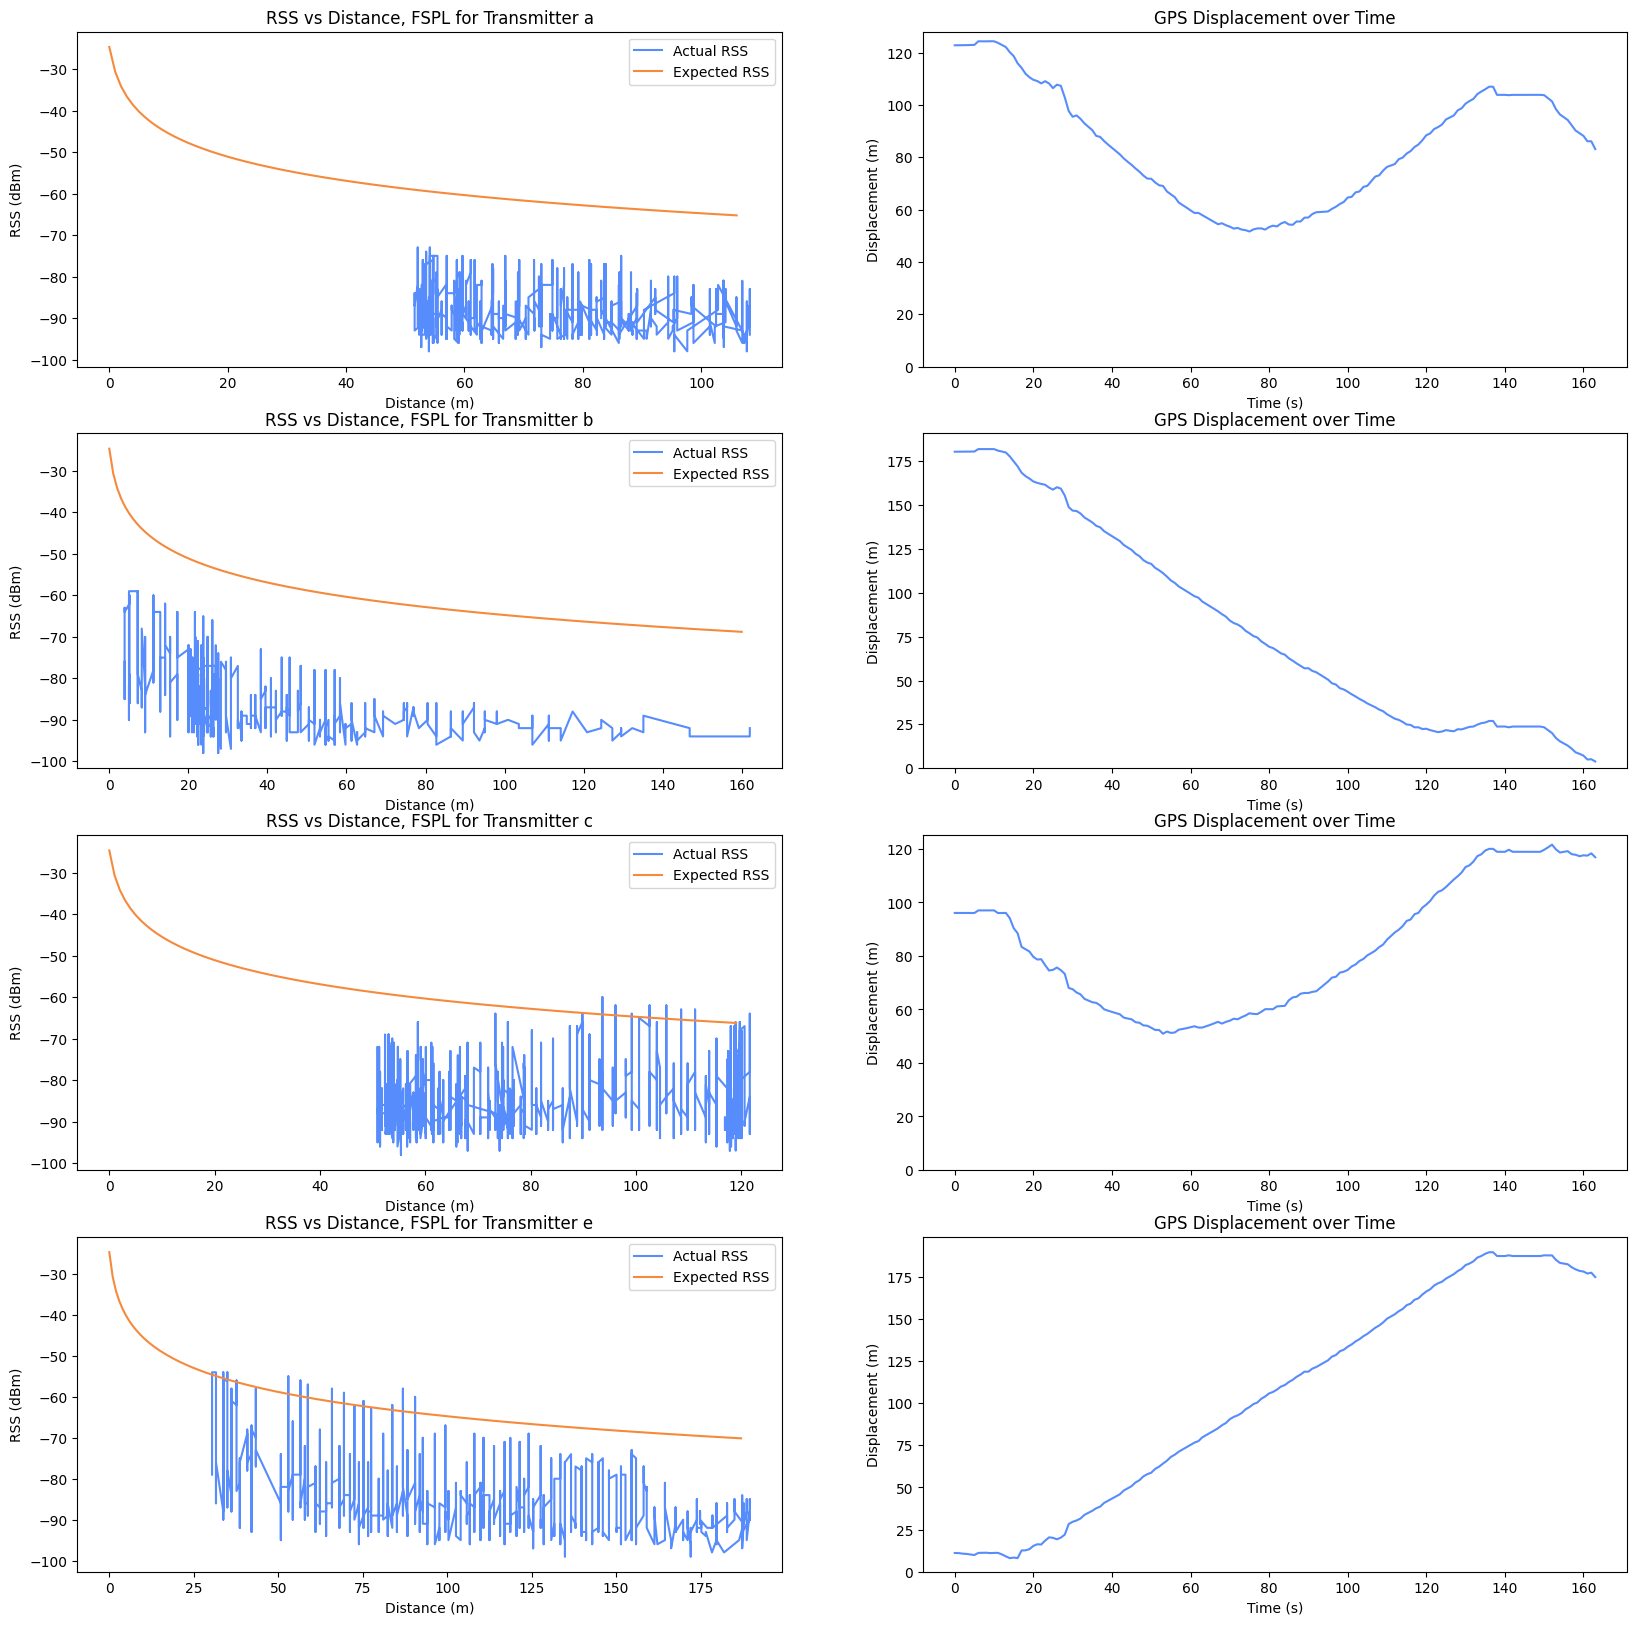

### straightpath6

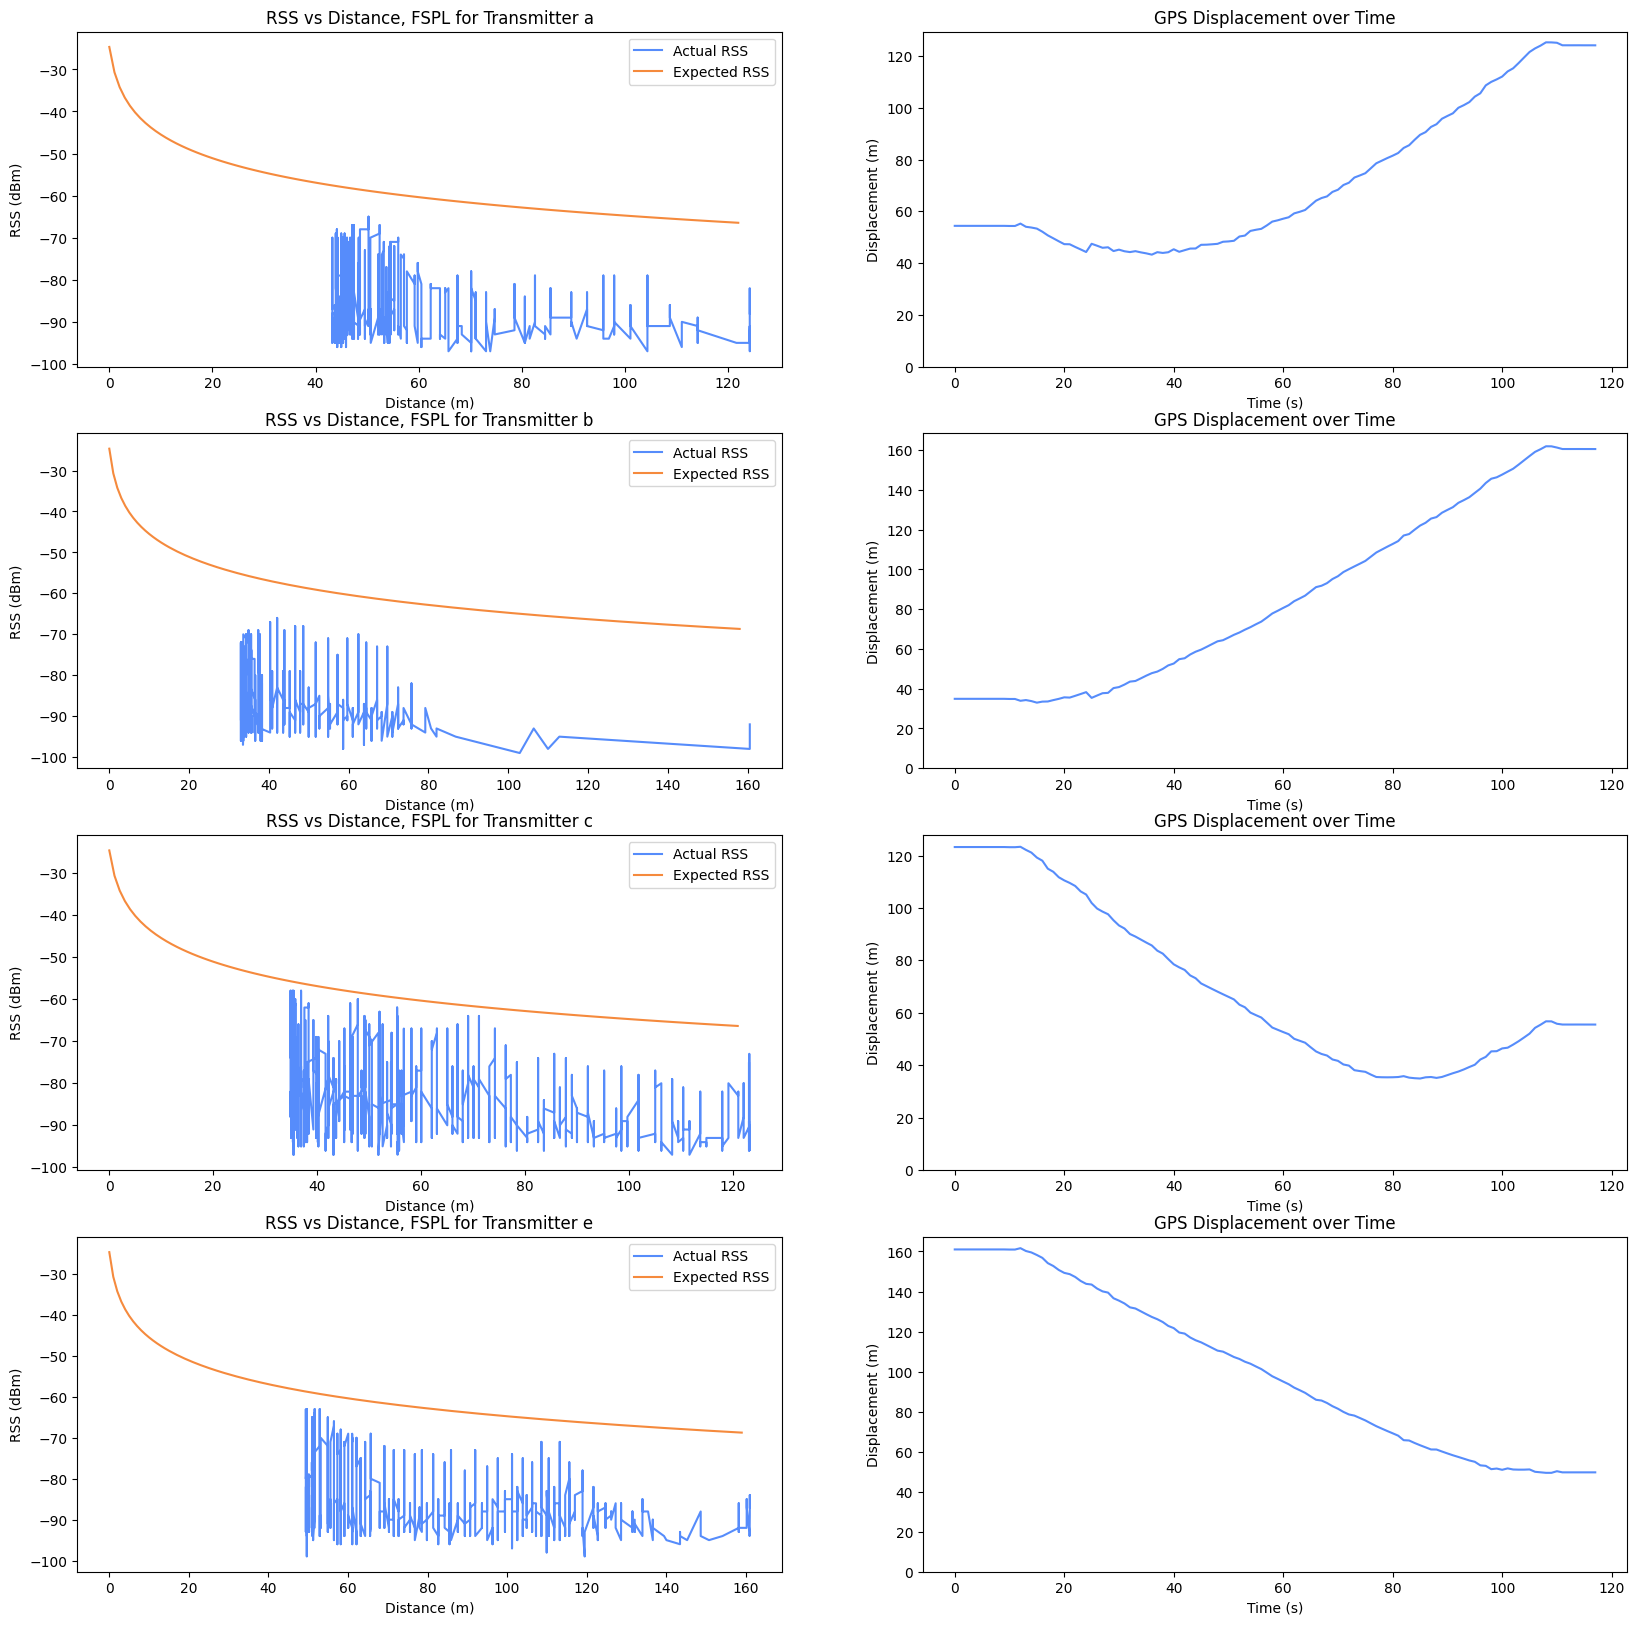

In [11]:
from IPython.display import display, Markdown

for name, logs in logs_with_names.items():
    display(Markdown(f"### {name}"))
    plt.figure(figsize=(20, 5*4))
    pos = 1

    for log in logs:
        plt.subplot(4, 2, pos)
        plot_rss_vs_dist_vs_fspl(log)

        plt.subplot(4, 2, pos + 1)
        plot_gps_displacement(log.gps_log)
        pos += 2

    plt.show()